<a href="https://colab.research.google.com/github/Kamo3131/MIO-fuzzy-logic/blob/more_parameters/MIO_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [45]:
# import os
# import pandas as pd
# FILE_NAME = "winequality-red.csv"
# full_file_path = os.path.join(DRIVE_PATH, FILE_NAME)

# df = pd.read_csv(full_file_path, sep=';')

# X = df.drop(columns=['quality'])
# y = df[['quality']]

# print("Rozmiar wczytanej macierzy cech X:", X.shape)
# print("Rozmiar wektora wyjściowego y:", y.shape)
# print("\nPierwsze 3 wiersze cech:")
# print(X.head(3))

import pandas as pd

# Bezpośredni link do pliku CSV na serwerach UCI
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# Pandas automatycznie pobierze i wczyta dane z internetu
df = pd.read_csv(URL, sep=';')

# Podział na macierz cech (X) i wektor wyjściowy (y)
X = df.drop(columns=['quality'])
y = df[['quality']]

print("Rozmiar wczytanej macierzy cech X:", X.shape)
print("Rozmiar wektora wyjściowego y:", y.shape)
print("\nPierwsze 3 wiersze cech:")
print(X.head(3))

Rozmiar wczytanej macierzy cech X: (1599, 11)
Rozmiar wektora wyjściowego y: (1599, 1)

Pierwsze 3 wiersze cech:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  
0      9.4  
1      9.8  
2      9.8  


In [46]:
print(X.describe())
print(y.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

In [47]:
import pandas as pd

full_data = pd.concat([X, y], axis=1)

correlations = full_data.corr()['quality'].sort_values(ascending=False)
print("Korelacja cech z jakością wina:")
print(correlations)

Korelacja cech z jakością wina:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [48]:
%pip install scikit-fuzzy pyswarms

Note: you may need to restart the kernel to use updated packages.


In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

wybrane_cechy = ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide', 'citric acid', 'density', 'fixed acidity', 'chlorides', 'residual sugar', 'pH', 'free sulfur dioxide']
X_reduced = X[wybrane_cechy]
X_reduced_min = dict()
X_reduced_max = dict()

for col in wybrane_cechy:
    min_val = X_reduced[col].min()
    max_val = X_reduced[col].max()
    X_reduced_min[col] = min_val
    X_reduced_max[col] = max_val
    print(f"Zmienna '{col}': zakres od {min_val} do {max_val}")

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

Zmienna 'alcohol': zakres od 8.4 do 14.9
Zmienna 'volatile acidity': zakres od 0.12 do 1.58
Zmienna 'sulphates': zakres od 0.33 do 2.0
Zmienna 'total sulfur dioxide': zakres od 6.0 do 289.0
Zmienna 'citric acid': zakres od 0.0 do 1.0
Zmienna 'density': zakres od 0.99007 do 1.00369
Zmienna 'fixed acidity': zakres od 4.6 do 15.9
Zmienna 'chlorides': zakres od 0.012 do 0.611
Zmienna 'residual sugar': zakres od 0.9 do 15.5
Zmienna 'pH': zakres od 2.74 do 4.01
Zmienna 'free sulfur dioxide': zakres od 1.0 do 72.0


In [50]:
#Zakresy

bounds = {
    'alc': (df['alcohol'].min(), df['alcohol'].max()),
    'vac': (df['volatile acidity'].min(), df['volatile acidity'].max()),
    'sul': (df['sulphates'].min(), df['sulphates'].max()),
    'tsd': (df['total sulfur dioxide'].min(), df['total sulfur dioxide'].max()),
    'cit': (df['citric acid'].min(), df['citric acid'].max()),
    'den': (df['density'].min(), df['density'].max()),
    'fix': (df['fixed acidity'].min(), df['fixed acidity'].max()),
    'chl': (df['chlorides'].min(), df['chlorides'].max()),
    'res': (df['residual sugar'].min(), df['residual sugar'].max()),
    'ph': (df['pH'].min(), df['pH'].max()),
    'fsod': (df['free sulfur dioxide'].min(), df['free sulfur dioxide'].max()),
    'qlt': (df['quality'].min(), df['quality'].max())
}

In [51]:
polowa = len(X_reduced) // 2

X_train = X_reduced.iloc[:polowa]
X_test = X_reduced.iloc[polowa:]

y_train = y.iloc[:polowa]
y_test = y.iloc[polowa:]

print(f"Wymiary zbioru uczącego: {X_train.shape}")
print(f"Wymiary zbioru testowego: {X_test.shape}")

Wymiary zbioru uczącego: (799, 11)
Wymiary zbioru testowego: (800, 11)


a:\Miniconda\envs\moj_colab\lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


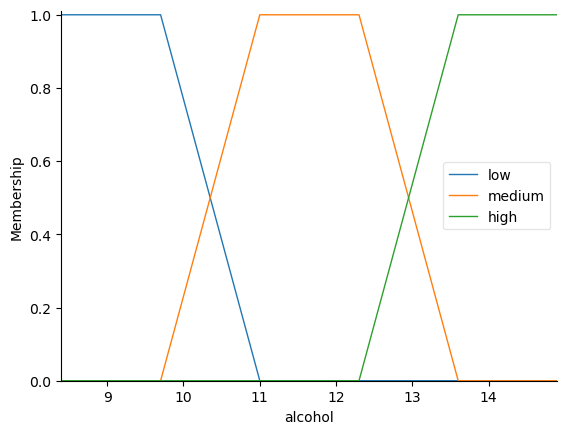

In [52]:
from skfuzzy import control as ctrl
import skfuzzy as fuzz
alcohol = ctrl.Antecedent(np.arange(X_reduced_min['alcohol'], X_reduced_max['alcohol']+0.1, 0.1), 'alcohol')

alcohol_dif = X_reduced_max['alcohol'] - X_reduced_min['alcohol']
alcohol['low'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol'],
                                               X_reduced_min['alcohol'],
                                               X_reduced_min['alcohol']+0.2*alcohol_dif,
                                               X_reduced_min['alcohol']+0.4*alcohol_dif])
alcohol['medium'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+0.2*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.4*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.6*alcohol_dif,
                                                  X_reduced_min['alcohol']+0.8*alcohol_dif])
alcohol['high'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+0.6*alcohol_dif,
                                                X_reduced_min['alcohol']+0.8*alcohol_dif,
                                                X_reduced_max['alcohol'],
                                                X_reduced_max['alcohol']])

alcohol.view()

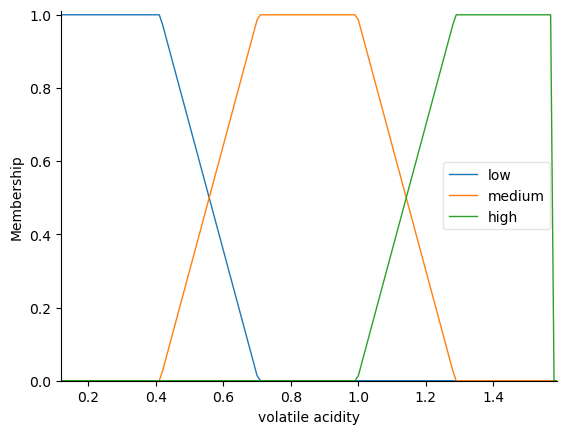

In [53]:
volatile_acidity = ctrl.Antecedent(np.arange(X_reduced_min['volatile acidity'], X_reduced_max['volatile acidity']+0.01, 0.01), 'volatile acidity')

volatile_acidity_dif = X_reduced_max['volatile acidity'] - X_reduced_min['volatile acidity']
volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity'],
                                               X_reduced_min['volatile acidity'],
                                               X_reduced_min['volatile acidity']+0.2*volatile_acidity_dif,
                                               X_reduced_min['volatile acidity']+0.4*volatile_acidity_dif])
volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+0.2*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.4*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.6*volatile_acidity_dif,
                                                  X_reduced_min['volatile acidity']+0.8*volatile_acidity_dif])
volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+0.6*volatile_acidity_dif,
                                                X_reduced_min['volatile acidity']+0.8*volatile_acidity_dif,
                                                X_reduced_max['volatile acidity'],
                                                X_reduced_max['volatile acidity']])

volatile_acidity.view()

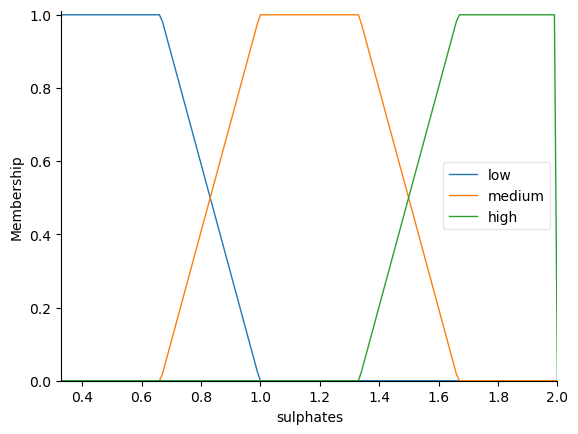

In [54]:
sulphates = ctrl.Antecedent(np.arange(X_reduced_min['sulphates'], X_reduced_max['sulphates']+0.01, 0.01), 'sulphates')

sulphates_dif = X_reduced_max['sulphates'] - X_reduced_min['sulphates']
sulphates['low'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates'],
                                               X_reduced_min['sulphates'],
                                               X_reduced_min['sulphates']+0.2*sulphates_dif,
                                               X_reduced_min['sulphates']+0.4*sulphates_dif])
sulphates['medium'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+0.2*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.4*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.6*sulphates_dif,
                                                  X_reduced_min['sulphates']+0.8*sulphates_dif])
sulphates['high'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+0.6*sulphates_dif,
                                                X_reduced_min['sulphates']+0.8*sulphates_dif,
                                                X_reduced_max['sulphates'],
                                                X_reduced_max['sulphates']])

sulphates.view()

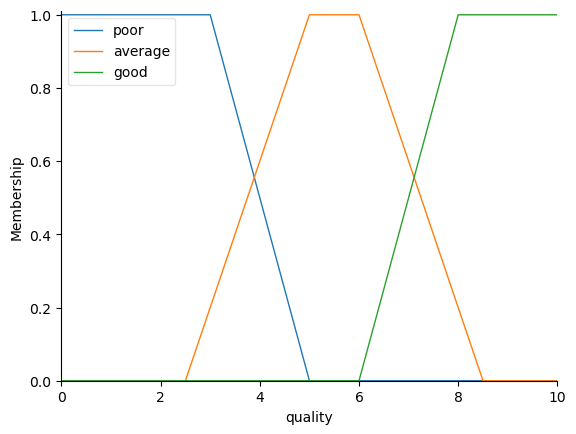

In [55]:
quality = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'quality')

quality['poor'] = fuzz.trapmf(quality.universe, [0, 0, 3, 5])
quality['average'] = fuzz.trapmf(quality.universe, [2.5, 5, 6, 8.5])
quality['good'] = fuzz.trapmf(quality.universe, [6, 8, 10, 10])

quality.view()

In [56]:
import itertools

waga_input = {
    'alcohol': {'low': 1, 'medium': 2, 'high': 3},
    'volatile_acidity': {'low': 3, 'medium': 2, 'high': 1},
    'sulphates': {'low': 1, 'medium': 2, 'high': 3}
}

rules = []

for alc, vac, sul in itertools.product(['low', 'medium', 'high'], repeat=3):
    score = waga_input['alcohol'][alc] + waga_input['volatile_acidity'][vac] + waga_input['sulphates'][sul]

    if score <= 4:
        out_quality = 'poor'
    elif score >= 8:
        out_quality = 'good'
    else:
        out_quality = 'average'

    rule = ctrl.Rule(alcohol[alc] & volatile_acidity[vac] & sulphates[sul], quality[out_quality])
    rules.append(rule)

control_system = ctrl.ControlSystem(rules)
model = ctrl.ControlSystemSimulation(control_system)

Model proponuje jakość:  8.4


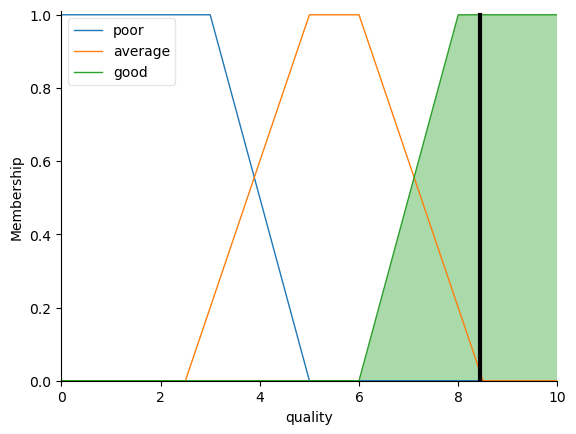

In [57]:
model.input['alcohol'] = 14.0
model.input['volatile acidity'] = 0.4
model.input['sulphates'] = 1.8

model.compute()

print('Model proponuje jakość: ', round(model.output['quality'], 1))
quality.view(sim=model)

In [58]:
from skfuzzy import control as ctrl
import skfuzzy as fuzz
import numpy as np
import itertools

def fuzzy_system_creator_trapmf(parameters):

    # p_alc = sorted(parameters[0:8])
    # p_vac = sorted(parameters[8:16])
    # p_sul = sorted(parameters[16:24])
    # p_qlt = sorted(parameters[24:32])

    # alcohol = ctrl.Antecedent(np.arange(X_reduced_min['alcohol'], X_reduced_max['alcohol']+0.1, 0.1), 'alcohol')

    # alcohol_dif = X_reduced_max['alcohol'] - X_reduced_min['alcohol']
    # alcohol['low'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol'],
    #                                               X_reduced_min['alcohol'],
    #                                               X_reduced_min['alcohol']+p_alc[0]*alcohol_dif,
    #                                               X_reduced_min['alcohol']+p_alc[1]*alcohol_dif])
    # alcohol['medium'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+p_alc[2]*alcohol_dif,
    #                                                   X_reduced_min['alcohol']+p_alc[3]*alcohol_dif,
    #                                                   X_reduced_min['alcohol']+p_alc[4]*alcohol_dif,
    #                                                   X_reduced_min['alcohol']+p_alc[5]*alcohol_dif])
    # alcohol['high'] = fuzz.trapmf(alcohol.universe, [X_reduced_min['alcohol']+p_alc[6]*alcohol_dif,
    #                                                 X_reduced_min['alcohol']+p_alc[7]*alcohol_dif,
    #                                                 X_reduced_max['alcohol'],
    #                                                 X_reduced_max['alcohol']])


    # volatile_acidity = ctrl.Antecedent(np.arange(X_reduced_min['volatile acidity'], X_reduced_max['volatile acidity']+0.01, 0.01), 'volatile acidity')

    # volatile_acidity_dif = X_reduced_max['volatile acidity'] - X_reduced_min['volatile acidity']
    # volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity'],
    #                                               X_reduced_min['volatile acidity'],
    #                                               X_reduced_min['volatile acidity']+p_vac[0]*volatile_acidity_dif,
    #                                               X_reduced_min['volatile acidity']+p_vac[1]*volatile_acidity_dif])
    # volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+p_vac[2]*volatile_acidity_dif,
    #                                                   X_reduced_min['volatile acidity']+p_vac[3]*volatile_acidity_dif,
    #                                                   X_reduced_min['volatile acidity']+p_vac[4]*volatile_acidity_dif,
    #                                                   X_reduced_min['volatile acidity']+p_vac[5]*volatile_acidity_dif])
    # volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [X_reduced_min['volatile acidity']+p_vac[6]*volatile_acidity_dif,
    #                                                 X_reduced_min['volatile acidity']+p_vac[7]*volatile_acidity_dif,
    #                                                 X_reduced_max['volatile acidity'],
    #                                                 X_reduced_max['volatile acidity']])

    # sulphates = ctrl.Antecedent(np.arange(X_reduced_min['sulphates'], X_reduced_max['sulphates']+0.01, 0.01), 'sulphates')

    # sulphates_dif = X_reduced_max['sulphates'] - X_reduced_min['sulphates']
    # sulphates['low'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates'],
    #                                               X_reduced_min['sulphates'],
    #                                               X_reduced_min['sulphates']+p_sul[0]*sulphates_dif,
    #                                               X_reduced_min['sulphates']+p_sul[1]*sulphates_dif])
    # sulphates['medium'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+p_sul[2]*sulphates_dif,
    #                                                   X_reduced_min['sulphates']+p_sul[3]*sulphates_dif,
    #                                                   X_reduced_min['sulphates']+p_sul[4]*sulphates_dif,
    #                                                   X_reduced_min['sulphates']+p_sul[5]*sulphates_dif])
    # sulphates['high'] = fuzz.trapmf(sulphates.universe, [X_reduced_min['sulphates']+p_sul[6]*sulphates_dif,
    #                                                 X_reduced_min['sulphates']+p_sul[7]*sulphates_dif,
    #                                                 X_reduced_max['sulphates'],
    #                                                 X_reduced_max['sulphates']])

    # quality = ctrl.Consequent(np.arange(0, 10.1, 0.1), 'quality')

    # quality['poor'] = fuzz.trapmf(quality.universe, [0, 0, p_qlt[0], p_qlt[1]])
    # quality['average'] = fuzz.trapmf(quality.universe, [p_qlt[2], p_qlt[3], p_qlt[4], p_qlt[5]])
    # quality['good'] = fuzz.trapmf(quality.universe, [p_qlt[6], p_qlt[7], 10, 10])

    alcohol = ctrl.Antecedent(np.linspace(bounds['alc'][0], bounds['alc'][1],100), 'alcohol')
    volatile_acidity = ctrl.Antecedent(np.linspace(bounds['vac'][0], bounds['vac'][1],100), 'volatile acidity')
    sulphates = ctrl.Antecedent(np.linspace(bounds['sul'][0], bounds['sul'][1],100), 'sulphates')
    quality = ctrl.Consequent(np.linspace(bounds['qlt'][0], bounds['qlt'][1],100), 'quality')

    p = np.sort(parameters[0:4])
    alcohol['low'] = fuzz.trapmf(alcohol.universe, [
        bounds['alc'][0],
        bounds['alc'][0],
        p[0],
        p[1]
    ])
    alcohol['medium'] = fuzz.trapmf(alcohol.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    alcohol['high'] = fuzz.trapmf(alcohol.universe, [
        p[2],
        p[3],
        bounds['alc'][1],
        bounds['alc'][1]
    ])

    p = np.sort(parameters[4:8])
    volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [
        bounds['vac'][0],
        bounds['vac'][0],
        p[0],
        p[1]
    ])
    volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [
        p[2],
        p[3],
        bounds['vac'][1],
        bounds['vac'][1]
    ])

    p = np.sort(parameters[8:12])
    sulphates['low'] = fuzz.trapmf(sulphates.universe, [
        bounds['sul'][0],
        bounds['sul'][0],
        p[0],
        p[1]
    ])
    sulphates['medium'] = fuzz.trapmf(sulphates.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    sulphates['high'] = fuzz.trapmf(sulphates.universe, [
        p[2],
        p[3],
        bounds['sul'][1],
        bounds['sul'][1]
    ])

    p = np.sort(parameters[12:16])
    quality['poor'] = fuzz.trapmf(quality.universe, [
        bounds['qlt'][0],
        bounds['qlt'][0],
        p[0],
        p[1]
    ])
    quality['average'] = fuzz.trapmf(quality.universe, [
        p[0],
        p[1],
        p[2],
        p[3]
    ])
    quality['good'] = fuzz.trapmf(quality.universe, [
        p[2],
        p[3],
        bounds['qlt'][1],
        bounds['qlt'][1]
    ])

    waga_input = {
    'alcohol': {'low': 1, 'medium': 2, 'high': 3},
    'volatile_acidity': {'low': 3, 'medium': 2, 'high': 1},
    'sulphates': {'low': 1, 'medium': 2, 'high': 3}
    }

    rules = []

    for alc, vac, sul in itertools.product(['low', 'medium', 'high'], repeat=3):
        score = waga_input['alcohol'][alc] + waga_input['volatile_acidity'][vac] + waga_input['sulphates'][sul]

        if score <= 4:
            out_quality = 'poor'
        elif score >= 8:
            out_quality = 'good'
        else:
            out_quality = 'average'

        rule = ctrl.Rule(alcohol[alc] & volatile_acidity[vac] & sulphates[sul], quality[out_quality])
        rules.append(rule)

    control_system = ctrl.ControlSystem(rules)
    model = ctrl.ControlSystemSimulation(control_system)

    return model, alcohol, volatile_acidity, sulphates, quality

### Validating `fuzzy_system_creator_trapmf`

Validating fuzzy_system_creator_trapmf...
Fuzzy system (trapmf) created successfully.


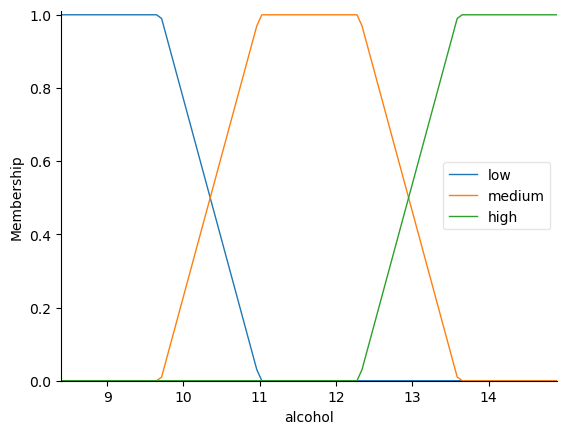

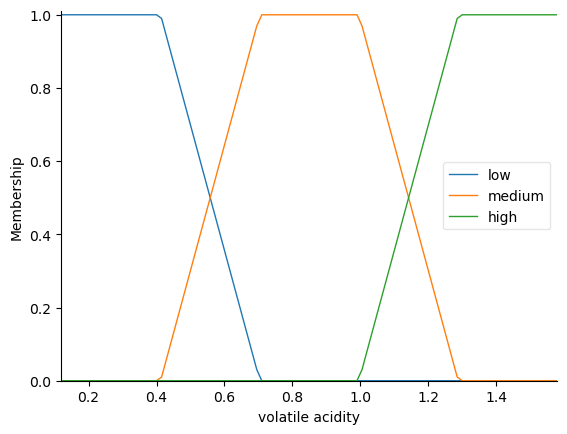

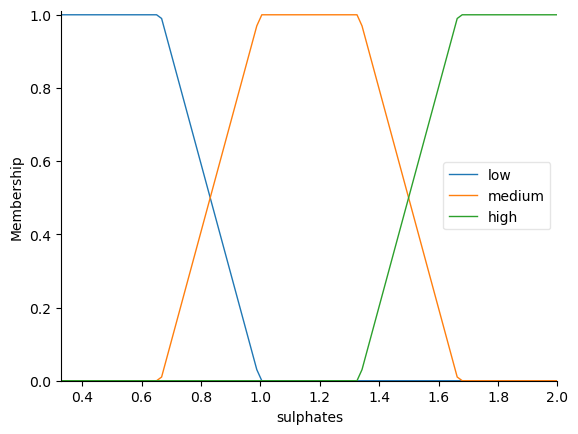

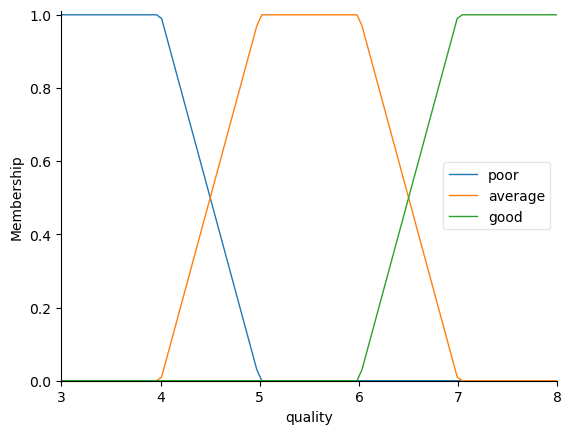

In [59]:
print('Validating fuzzy_system_creator_trapmf...')

# Dummy parameters for trapezoidal membership functions (4 * 4 = 16 parameters)
# For simplicity, let's distribute them evenly within the bounds for each variable.
# alcohol: 4 parameters, volatile_acidity: 4, sulphates: 4, quality: 4
dummy_params_trapmf = np.array([
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.1,  # alc low_a
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.2,  # alc low_b
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.3,  # alc med_a
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.4,  # alc med_b
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.6,  # alc med_c
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.7,  # alc med_d
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.8,  # alc high_c
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.9,  # alc high_d

    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.1,  # vac low_a
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.2,  # vac low_b
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.3,  # vac med_a
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.4,  # vac med_b
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.6,  # vac med_c
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.7,  # vac med_d
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.8,  # vac high_c
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.9,  # vac high_d

    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.1,  # sul low_a
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.2,  # sul low_b
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.3,  # sul med_a
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.4,  # sul med_b
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.6,  # sul med_c
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.7,  # sul med_d
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.8,  # sul high_c
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.9,  # sul high_d

    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.1,  # qlt poor_a
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.3,  # qlt poor_b
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.4,  # qlt avg_a
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.6,  # qlt avg_b
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.7,  # qlt avg_c
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.9,  # qlt avg_d
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.8,  # qlt good_c
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.9  # qlt good_d
])

# Ensure the array has the correct shape for the function (16 parameters if it is 4 per each)
# Let's re-evaluate the expected number of parameters for fuzzy_system_creator_trapmf based on the function's internal parameter slicing.
# The function has 'p = np.sort(parameters[0:4])' for alcohol, and similar for others.
# This means 4 parameters per variable. Total 4 variables (alcohol, volatile acidity, sulphates, quality) = 16 parameters.

# Let's use a simpler dummy_params_trapmf with 16 elements, ensuring they are sorted within their respective groups if needed by the function.

dummy_params_trapmf_corrected = np.array([
    bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.2, bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.4, bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.6, bounds['alc'][0] + (bounds['alc'][1] - bounds['alc'][0]) * 0.8, # alcohol
    bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.2, bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.4, bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.6, bounds['vac'][0] + (bounds['vac'][1] - bounds['vac'][0]) * 0.8, # volatile acidity
    bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.2, bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.4, bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.6, bounds['sul'][0] + (bounds['sul'][1] - bounds['sul'][0]) * 0.8, # sulphates
    bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.2, bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.4, bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.6, bounds['qlt'][0] + (bounds['qlt'][1] - bounds['qlt'][0]) * 0.8  # quality
])

sys_trapmf, alcohol_trapmf, volatile_acidity_trapmf, sulphates_trapmf, quality_trapmf = fuzzy_system_creator_trapmf(dummy_params_trapmf_corrected)

print("Fuzzy system (trapmf) created successfully.")

alcohol_trapmf.view()
volatile_acidity_trapmf.view()
sulphates_trapmf.view()
quality_trapmf.view()

In [60]:
import pandas as pd
import skfuzzy as fuzz
from sklearn.metrics import mean_squared_error
import pyswarms as ps
import requests
import io

# ---------------------------------------------------------
# 3. OPTYMALIZACJA PSO
# ---------------------------------------------------------
def fitness_function(swarm_params):
    n_particles = swarm_params.shape[0]
    results = []

    # Dla przyspieszenia obliczeń w PSO używamy podzbioru danych treningowych
    X_sub_np = X_train[:50].values # Convert X_sub to a numpy array for robust iteration
    y_sub_flat = y_train[:50].values.flatten() # Convert y_sub to a 1D numpy array

    default_prediction = y_sub_flat.mean()

    for i in range(n_particles):
        try:
            # Correctly unpack the tuple returned by fuzzy_system_creator_trapmf
            sim_model, _, _, _, _ = fuzzy_system_creator_trapmf(swarm_params[i])

            preds_particle = np.full(len(X_sub_np), default_prediction) # Initialize predictions for current particle

            for j, val in enumerate(X_sub_np):
                try:
                    sim_model.input['alcohol'] = val[0]
                    sim_model.input['volatile acidity'] = val[1]
                    sim_model.input['sulphates'] = val[2]
                    sim_model.compute()
                    preds_particle[j] = sim_model.output['quality']
                except:
                    # If computation fails for a specific input, the default_prediction
                    # for this index in 'preds_particle' will remain.
                    pass

            # Both y_sub_flat and preds_particle are now 1D numpy arrays of the same length
            results.append(mean_squared_error(y_sub_flat, preds_particle))
        except Exception as e:
            # This outer except block catches errors during fuzzy system creation itself
            # or other unexpected issues before prediction calculation.
            results.append(100.0) # Penalty for a failed fuzzy system

    return np.array(results)

In [61]:
def evaluate(model, X, y):
    # Initialize predictions with a default value (e.g., mean of y_true)
    # This ensures `preds` always has the same length as `y`.
    default_prediction = np.mean(y)
    preds = np.full(len(X), default_prediction)

    for i, val in enumerate(X.values):
        try:
            model.input['alcohol'] = val[0]
            model.input['volatile acidity'] = val[1]
            model.input['sulphates'] = val[2]
            model.compute()
            preds[i] = model.output['quality']
        except:
            # If computation fails for this specific input, the default_prediction
            # for this index in 'preds' will remain.
            pass # The default value in preds will be used for this entry.
    return mean_squared_error(y, preds)

In [62]:
# import numpy as np
# from tqdm.auto import tqdm  # Importujemy moduł tqdm (auto samo dostosuje wygląd do Jupyter)

# class TimeTravelPSO:
#     """
#     Drop-in replacement dla pyswarms.single.GlobalBestPSO z algorytmem Time Travel.
#     Dodano pasek postępu z użyciem biblioteki tqdm.
#     """
#     def __init__(self, n_particles, dimensions, options, bounds=None):
#         self.n_particles = n_particles
#         self.dimensions = dimensions
#         self.options = options
#         self.bounds = bounds

#         self.c1 = options.get('c1', 1.5)
#         self.c2 = options.get('c2', 1.5)
#         self.w = options.get('w', 0.9)

#         # Inicjalizacja pozycji i prędkości
#         if bounds is not None:
#             min_b, max_b = bounds
#             self.pos = np.random.uniform(min_b, max_b, (n_particles, dimensions))
#         else:
#             self.pos = np.random.uniform(-1, 1, (n_particles, dimensions))

#         self.vel = np.zeros((n_particles, dimensions))

#         self.pbest_pos = self.pos.copy()
#         self.pbest_cost = np.full(n_particles, np.inf)

#         self.gbest_pos = None
#         self.gbest_cost = np.inf

#         # Historia na potrzeby Time Travel i zapisywania wyników
#         self.history_pos = []
#         self.cost_history = []

#     def optimize(self, objective_func, iters):
#         # Oplatamy range(iters) funkcją tqdm, która wygeneruje pasek postępu
#         for i in tqdm(range(iters), desc="TimeTravelPSO Progress"):
#             # Zapisz obecną pozycję na potrzeby Time Travel
#             self.history_pos.append(self.pos.copy())

#             # Ewaluacja kosztów
#             costs = objective_func(self.pos)

#             # Aktualizacja personal best (pbest)
#             improved = costs < self.pbest_cost
#             self.pbest_pos[improved] = self.pos[improved]
#             self.pbest_cost[improved] = costs[improved]

#             # Aktualizacja global best (gbest)
#             min_cost_idx = np.argmin(self.pbest_cost)
#             if self.pbest_cost[min_cost_idx] < self.gbest_cost:
#                 self.gbest_cost = self.pbest_cost[min_cost_idx]
#                 self.gbest_pos = self.pbest_pos[min_cost_idx].copy()

#             self.cost_history.append(self.gbest_cost)

#             # Time Travel Mechanism
#             if i > 0:
#                 stagnant = ~improved
#                 for idx in range(self.n_particles):
#                     if stagnant[idx] and np.random.rand() < 0.2:
#                         past_iter = np.random.randint(0, i)
#                         self.pos[idx] = self.history_pos[past_iter][idx]

#             # Standardowa aktualizacja prędkości i przemieszczenia (PSO)
#             r1 = np.random.rand(self.n_particles, self.dimensions)
#             r2 = np.random.rand(self.n_particles, self.dimensions)

#             self.vel = (self.w * self.vel +
#                         self.c1 * r1 * (self.pbest_pos - self.pos) +
#                         self.c2 * r2 * (self.gbest_pos - self.pos))

#             self.pos = self.pos + self.vel

#             # Ograniczenia zakresu poszukiwań (bounds)
#             if self.bounds is not None:
#                 min_b, max_b = self.bounds
#                 self.pos = np.clip(self.pos, min_b, max_b)

#         return self.gbest_cost, self.gbest_pos

In [63]:
import numpy as np
from tqdm.auto import tqdm
from collections import deque

class TimeTravelPSO:
    """
    Drop-in replacement dla pyswarms.single.GlobalBestPSO z ulepszonym 
    i bezpiecznym pamięciowo algorytmem Time Travel.
    """
    def __init__(self, n_particles, dimensions, options, bounds=None):
        self.n_particles = n_particles
        self.dimensions = dimensions
        self.options = options
        self.bounds = bounds

        # Standardowe parametry PSO
        self.c1 = options.get('c1', 1.5)
        self.c2 = options.get('c2', 1.5)
        self.w = options.get('w', 0.9)

        # Nowe parametry dla mechanizmu Time Travel
        self.tt_patience = options.get('tt_patience', 10)  # Ile iteracji bez poprawy oznacza stagnację
        self.tt_prob = options.get('tt_prob', 0.2)         # Szansa na skok w czasie (np. 20%)
        self.history_len = options.get('history_len', 50)  # Maksymalna liczba pamiętanych iteracji wstecz

        # Inicjalizacja pozycji i prędkości
        if bounds is not None:
            min_b, max_b = bounds
            self.pos = np.random.uniform(min_b, max_b, (n_particles, dimensions))
        else:
            self.pos = np.random.uniform(-1, 1, (n_particles, dimensions))

        self.vel = np.zeros((n_particles, dimensions))

        self.pbest_pos = self.pos.copy()
        self.pbest_cost = np.full(n_particles, np.inf)

        self.gbest_pos = None
        self.gbest_cost = np.inf

        # FIX: Użycie deque z maxlen rozwiązuje problem pożerania pamięci RAM
        self.history_pos = deque(maxlen=self.history_len)
        self.cost_history = []
        
        # FIX: Licznik stagnacji dla każdej cząsteczki
        self.stagnation_counter = np.zeros(n_particles, dtype=int)

    def optimize(self, objective_func, iters):
        for i in tqdm(range(iters), desc="TimeTravelPSO Progress"):
            # Zapis historii do bufora kołowego
            self.history_pos.append(self.pos.copy())

            # Ewaluacja kosztów
            costs = objective_func(self.pos)

            # Aktualizacja personal best (pbest)
            improved = costs < self.pbest_cost
            self.pbest_pos[improved] = self.pos[improved]
            self.pbest_cost[improved] = costs[improved]

            # Aktualizacja licznika stagnacji
            self.stagnation_counter[improved] = 0        # Reset przy poprawie
            self.stagnation_counter[~improved] += 1      # Zwiększenie przy braku poprawy

            # Aktualizacja global best (gbest)
            min_cost_idx = np.argmin(self.pbest_cost)
            if self.pbest_cost[min_cost_idx] < self.gbest_cost:
                self.gbest_cost = self.pbest_cost[min_cost_idx]
                self.gbest_pos = self.pbest_pos[min_cost_idx].copy()

            self.cost_history.append(self.gbest_cost)

            # --- Mechanizm Time Travel ---
            if len(self.history_pos) > 1:
                # Kto przekroczył limit cierpliwości?
                stagnant_particles = self.stagnation_counter >= self.tt_patience
                
                for idx in range(self.n_particles):
                    if stagnant_particles[idx] and np.random.rand() < self.tt_prob:
                        # Wybierz losowy moment z dostępnej historii
                        past_idx = np.random.randint(0, len(self.history_pos) - 1)
                        self.pos[idx] = self.history_pos[past_idx][idx]
                        
                        # FIX: Wyzerowanie prędkości, by cząsteczka nie wystrzeliła losowo
                        self.vel[idx] = 0.0
                        
                        # Reset licznika stagnacji po skoku w czasie
                        self.stagnation_counter[idx] = 0

            # Standardowa aktualizacja prędkości i przemieszczenia (zoptymalizowana wektorowo)
            r1 = np.random.rand(self.n_particles, self.dimensions)
            r2 = np.random.rand(self.n_particles, self.dimensions)

            self.vel = (self.w * self.vel +
                        self.c1 * r1 * (self.pbest_pos - self.pos) +
                        self.c2 * r2 * (self.gbest_pos - self.pos))

            self.pos = self.pos + self.vel

            # Ograniczenia zakresu poszukiwań (bounds)
            if self.bounds is not None:
                min_b, max_b = self.bounds
                self.pos = np.clip(self.pos, min_b, max_b)

        return self.gbest_cost, self.gbest_pos

In [64]:
import pyswarms as ps
import matplotlib.pyplot as plt

def run_pso_and_get_history_TimeTravelPSO(n_particles, dimensions, iters, options, pso_bounds, fitness_function, X_test, y_test, csv_filename=None):
    """
    Runs PSO optimization, collects cost history, and evaluates the best model on the test set.

    Args:
        n_particles (int): Number of particles in the swarm.
        dimensions (int): Number of dimensions (parameters) to optimize.
        iters (int): Number of iterations for the optimizer.
        options (dict): Dictionary of PSO options (c1, c2, w).
        pso_bounds (tuple): Tuple of (min_bound, max_bound) for the search space.
        fitness_function (function): The fitness function to optimize.
        X_test (pd.DataFrame): Test feature data.
        y_test (pd.DataFrame): Test target data.

    Returns:
        tuple: (final_best_cost, best_position, cost_history, mse_on_test_set)
    """
    # optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
    # best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

    optimizer = TimeTravelPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
    best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

    cost_history = optimizer.cost_history

    # Eksport historii do CSV
    if csv_filename:
        df_hist = pd.DataFrame({
            'Iteracja': range(1, len(cost_history) + 1),
            'MSE': cost_history
        })
        df_hist.to_csv(csv_filename, index=False)
        print(f"Zapisano historię optymalizacji do pliku: {csv_filename}")

    # Evaluate the best found position on the test set
    # fuzzy_system_creator_trapmf returns a tuple, we need only the model (first element)
    sim_model_best_pso, _, _, _, _ = fuzzy_system_creator_trapmf(best_pos)
    mse_on_test_set = evaluate(sim_model_best_pso, X_test, y_test)

    return best_cost, best_pos, cost_history, mse_on_test_set


### PSO Optimization: `c1 = c2`

Let's run PSO with `c1` and `c2` set to equal values (e.g., `c1=0.7`, `c2=0.7`). We'll track the MSE history and visualize it.

Creating initial fuzzy system using genfis_trapmf_matlab_like...
Initial fuzzy system created successfully using genfis_trapmf_matlab_like.


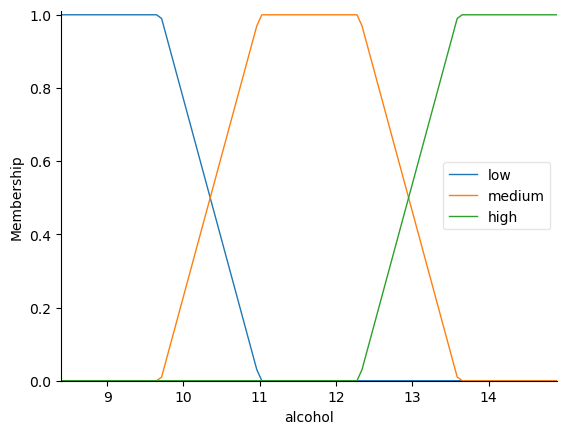

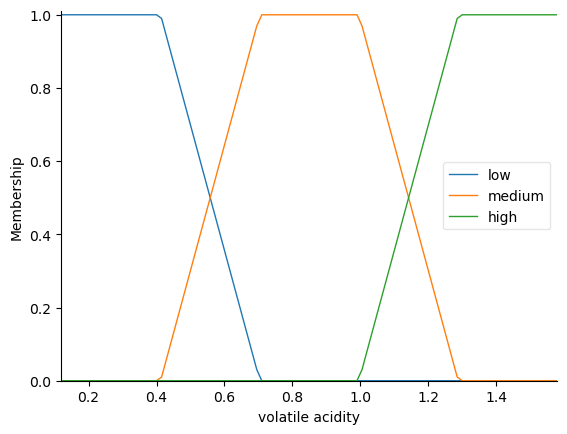

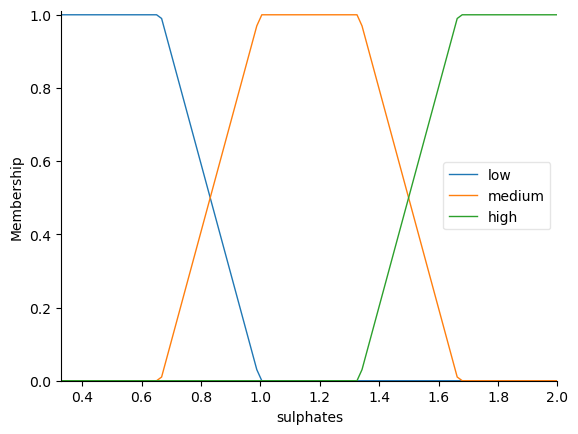

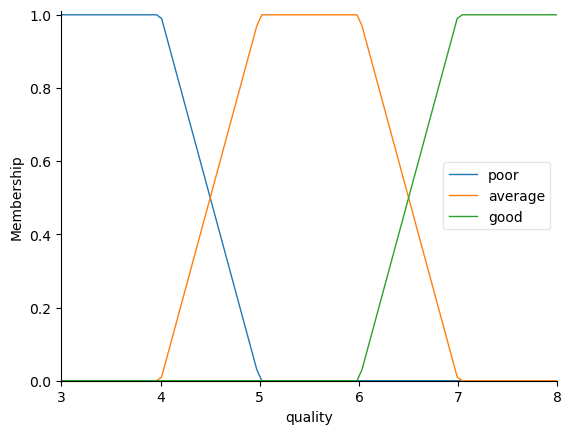

In [65]:
import numpy as np

# Zakresy poszukiwań dla PSO (znormalizowane do zakresów zmiennych)
max_bound = np.array([bounds['alc'][1]]*4 + [bounds['vac'][1]]*4 + [bounds['sul'][1]]*4 + [bounds['qlt'][1]]*4)
min_bound = np.array([bounds['alc'][0]]*4 + [bounds['vac'][0]]*4 + [bounds['sul'][0]]*4 + [bounds['qlt'][0]]*4) # Corrected bounds['sul'][1] to bounds['sul'][0]
pso_bounds = (min_bound, max_bound)

def generate_initial_trapmf_params(bounds):
    """
    Generates initial parameters for trapezoidal membership functions.
    These parameters are structured for use with fuzzy_system_creator_trapmf,
    ensuring the 'a <= b <= c <= d' condition for trapezoids.

    Args:
        bounds (dict): A dictionary containing min/max bounds for each variable
                       ('alc', 'vac', 'sul', 'qlt').

    Returns:
        np.array: A 1D numpy array of 16 parameters (4 for each of 4 variables).
    """
    min_bound, max_bound = bounds
    all_params = []
    # Order of variables as expected by fuzzy_system_creator_trapmf
    variable_keys = ['alc', 'vac', 'sul', 'qlt']

    # These points define the 'shoulders' and 'feet' of the trapezoidal MFs.
    # The fuzzy_system_creator_trapmf function uses these points to define:
    # 'low':    [min, min, p[0], p[1]]
    # 'medium': [p[0], p[1], p[2], p[3]]
    # 'high':   [p[2], p[3], max, max]
    # We ensure p[0] <= p[1] <= p[2] <= p[3] and they are within [min, max].

    # Using quartiles of the range for a reasonable initial spread.
    # These percentages can be adjusted for different initial distributions.
    relative_points = [0.20, 0.40, 0.60, 0.80]

    # for key in variable_keys:
    #     min_val, max_val = bounds[key]
    #     value_range = max_val - min_val

    #     # Calculate the 4 points for the current variable
    #     p0 = min_val + (value_range * relative_points[0])
    #     p1 = min_val + (value_range * relative_points[1])
    #     p2 = min_val + (value_range * relative_points[2])
    #     p3 = min_val + (value_range * relative_points[3])

    #     current_var_params = [p0, p1, p2, p3]
    #     all_params.extend(current_var_params)
    for idx, key in enumerate(variable_keys):
        # Ponieważ min_bound i max_bound pakują po 4 elementy dla każdej zmiennej:
        # alc: 0-3, vac: 4-7, sul: 8-11, qlt: 12-15
        start_idx = idx * 4
        min_val = min_bound[start_idx]
        max_val = max_bound[start_idx]
        value_range = max_val - min_val

        # Calculate the 4 points for the current variable
        p0 = min_val + (value_range * relative_points[0])
        p1 = min_val + (value_range * relative_points[1])
        p2 = min_val + (value_range * relative_points[2])
        p3 = min_val + (value_range * relative_points[3])

        current_var_params = [p0, p1, p2, p3]
        all_params.extend(current_var_params)

    return np.array(all_params)

def genfis_trapmf_matlab_like(bounds):
    """
    Generates an initial fuzzy inference system (FIS) using trapezoidal membership functions,
    similar to how 'genfis' might initialize a system in MATLAB for grid partitioning.

    Args:
        bounds (dict): A dictionary containing min/max bounds for each variable
                       ('alc', 'vac', 'sul', 'qlt').

    Returns:
        tuple: A tuple containing the control system simulation object, and the
               antecedent/consequent fuzzy variables (alcohol, volatile_acidity,
               sulphates, quality).
    """
    initial_params = generate_initial_trapmf_params(bounds)
    return fuzzy_system_creator_trapmf(initial_params)

# Now, use this function to create the model
print('Creating initial fuzzy system using genfis_trapmf_matlab_like...')
model_genfis, alc_genfis, vac_genfis, sul_genfis, qlt_genfis = genfis_trapmf_matlab_like(pso_bounds)
print('Initial fuzzy system created successfully using genfis_trapmf_matlab_like.')

# Optionally, view the generated membership functions
alc_genfis.view()
vac_genfis.view()
sul_genfis.view()
qlt_genfis.view()

Running PSO with c1=c2 (2 iterations)...


TimeTravelPSO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: TimeTravelPSO_c1_eq_c2_history.csv
Final Best Cost (c1=c2): 0.8804
MSE on Test Set (c1=c2): 1.7444


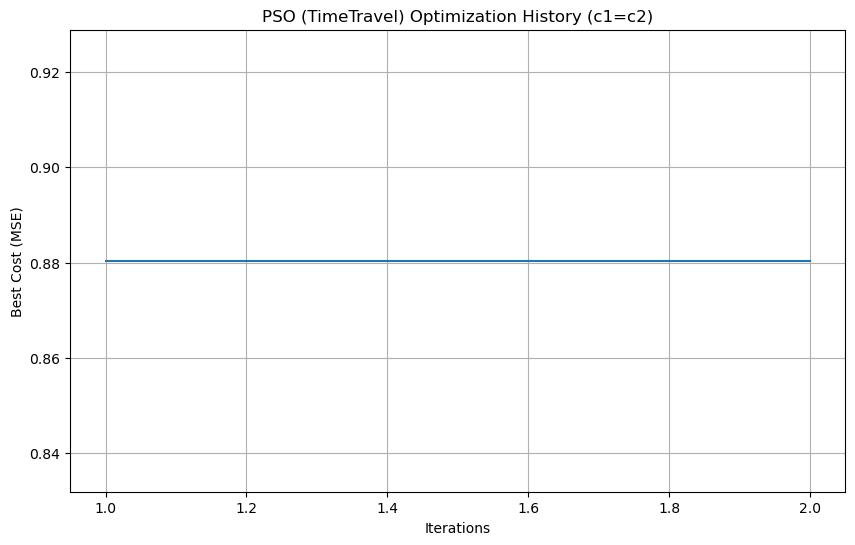

In [66]:
# Configuration for c1 = c2
n_particles = 5
dimensions = 16 # Number of parameters for trapezoidal MFs
iters = 2 # Using the max of range(2,7,2) as requested
options_c1_eq_c2 = {'c1': 0.7, 'c2': 0.7, 'w': 0.9}

print("Running PSO with c1=c2 ({} iterations)...".format(iters))
best_cost_eq, best_pos_eq, cost_history_eq, mse_pso_eq = run_pso_and_get_history_TimeTravelPSO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_eq_c2,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="TimeTravelPSO_c1_eq_c2_history.csv"
)

print(f"Final Best Cost (c1=c2): {best_cost_eq:.4f}")
print(f"MSE on Test Set (c1=c2): {mse_pso_eq:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_eq)
plt.title('PSO (TimeTravel) Optimization History (c1=c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


### PSO Optimization: `c1 < c2`

Next, let's test a configuration where `c1` is less than `c2` (e.g., `c1=0.5`, `c2=0.8`).

Running PSO with c1<c2 (2 iterations)...


TimeTravelPSO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: TimeTravelPSO_c1_lt_c2_history.csv
Final Best Cost (c1<c2): 0.5040
MSE on Test Set (c1<c2): 0.7186


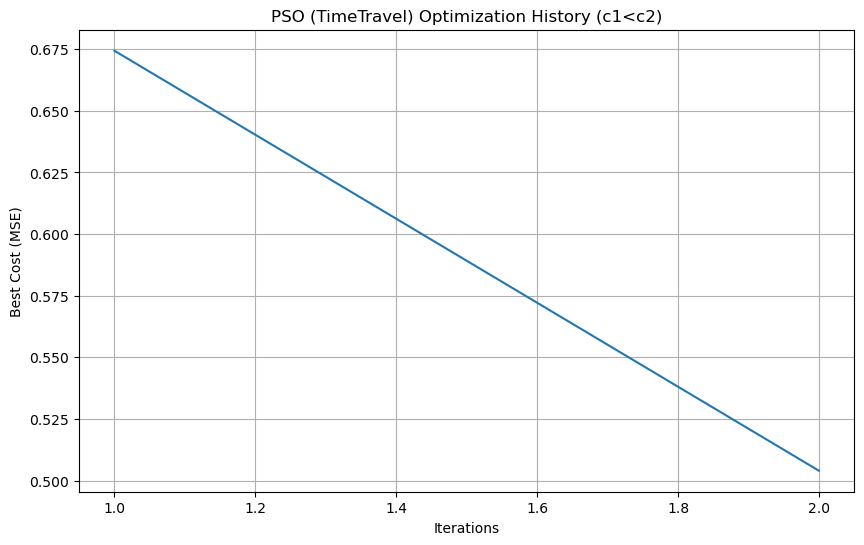

In [67]:
# Configuration for c1 < c2
options_c1_lt_c2 = {'c1': 0.5, 'c2': 0.8, 'w': 0.9}

print("Running PSO with c1<c2 ({} iterations)...".format(iters))
best_cost_lt, best_pos_lt, cost_history_lt, mse_pso_lt = run_pso_and_get_history_TimeTravelPSO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_lt_c2,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="TimeTravelPSO_c1_lt_c2_history.csv"
)

print(f"Final Best Cost (c1<c2): {best_cost_lt:.4f}")
print(f"MSE on Test Set (c1<c2): {mse_pso_lt:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_lt)
plt.title('PSO (TimeTravel) Optimization History (c1<c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


### PSO Optimization: `c1 > c2`

Finally, let's explore a scenario where `c1` is greater than `c2` (e.g., `c1=0.8`, `c2=0.5`).

Running PSO with c1>c2 (2 iterations)...


TimeTravelPSO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: TimeTravelPSO_c1_gt_c2_history.csv
Final Best Cost (c1>c2): 0.5154
MSE on Test Set (c1>c2): 1.0002


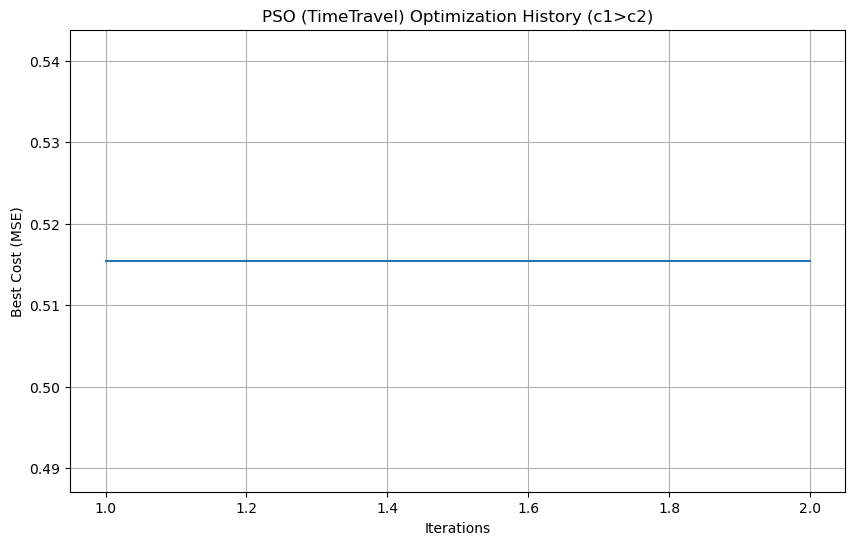

In [68]:
# Configuration for c1 > c2
options_c1_gt_c2 = {'c1': 0.8, 'c2': 0.5, 'w': 0.9}

print("Running PSO with c1>c2 ({} iterations)...".format(iters))
best_cost_gt, best_pos_gt, cost_history_gt, mse_pso_gt = run_pso_and_get_history_TimeTravelPSO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_gt_c2,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="TimeTravelPSO_c1_gt_c2_history.csv"
)

print(f"Final Best Cost (c1>c2): {best_cost_gt:.4f}")
print(f"MSE on Test Set (c1>c2): {mse_pso_gt:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gt)
plt.title('PSO (TimeTravel) Optimization History (c1>c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


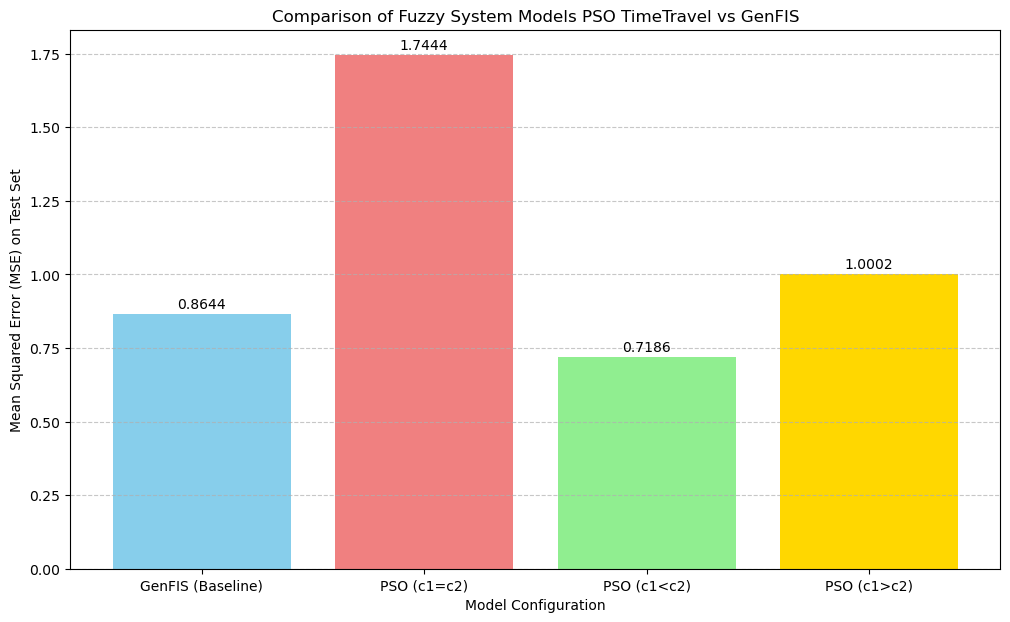

In [69]:
# Data for comparison
model_names = [
    "GenFIS (Baseline)",
    "PSO (c1=c2)",
    "PSO (c1<c2)",
    "PSO (c1>c2)"
]

mse_genfis = evaluate(model_genfis, X_test, y_test)

mse_values = [
    mse_genfis,
    mse_pso_eq,
    mse_pso_lt,
    mse_pso_gt
]

plt.figure(figsize=(12, 7))
plt.bar(model_names, mse_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Model Configuration')
plt.ylabel('Mean Squared Error (MSE) on Test Set')
plt.title('Comparison of Fuzzy System Models PSO TimeTravel vs GenFIS')
plt.ylim(bottom=0) # Ensure y-axis starts from 0

for i, mse in enumerate(mse_values):
    plt.text(i, mse + 0.01, f'{mse:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### PSO with Pyswarm


In [70]:
import pyswarms as ps
import matplotlib.pyplot as plt

def run_pso_and_get_history_PSOPyswarms(n_particles, dimensions, iters, options, pso_bounds, fitness_function, X_test, y_test, csv_filename=None):
    """
    Runs PSO optimization, collects cost history, and evaluates the best model on the test set.

    Args:
        n_particles (int): Number of particles in the swarm.
        dimensions (int): Number of dimensions (parameters) to optimize.
        iters (int): Number of iterations for the optimizer.
        options (dict): Dictionary of PSO options (c1, c2, w).
        pso_bounds (tuple): Tuple of (min_bound, max_bound) for the search space.
        fitness_function (function): The fitness function to optimize.
        X_test (pd.DataFrame): Test feature data.
        y_test (pd.DataFrame): Test target data.

    Returns:
        tuple: (final_best_cost, best_position, cost_history, mse_on_test_set)
    """
    # optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
    # best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

    optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
    best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

    cost_history = optimizer.cost_history

    # Eksport historii do CSV
    if csv_filename:
        df_hist = pd.DataFrame({
            'Iteracja': range(1, len(cost_history) + 1),
            'MSE': cost_history
        })
        df_hist.to_csv(csv_filename, index=False)
        print(f"Zapisano historię optymalizacji do pliku: {csv_filename}")

    # Evaluate the best found position on the test set
    # fuzzy_system_creator_trapmf returns a tuple, we need only the model (first element)
    sim_model_best_pso, _, _, _, _ = fuzzy_system_creator_trapmf(best_pos)
    mse_on_test_set = evaluate(sim_model_best_pso, X_test, y_test)

    return best_cost, best_pos, cost_history, mse_on_test_set


2026-06-08 22:21:40,086 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.7, 'c2': 0.7, 'w': 0.9}


Running PSO with c1=c2 (2 iterations)...


pyswarms.single.global_best: 100%|██████████|2/2, best_cost=0.608
2026-06-08 22:21:48,701 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.6084461672895238, best pos: [11.59183146 12.97074592  9.12954716 12.05914715  0.45327341  1.25948367
  0.9925785   0.9769652   0.71154269  0.89042954  0.77254237  0.97186356
  3.70553677  6.69946518  5.56812642  5.33735606]


Zapisano historię optymalizacji do pliku: PyswarmsPSO_c1_eq_c2_history.csv
Final Best Cost (c1=c2): 0.6084
MSE on Test Set (c1=c2): 0.8797


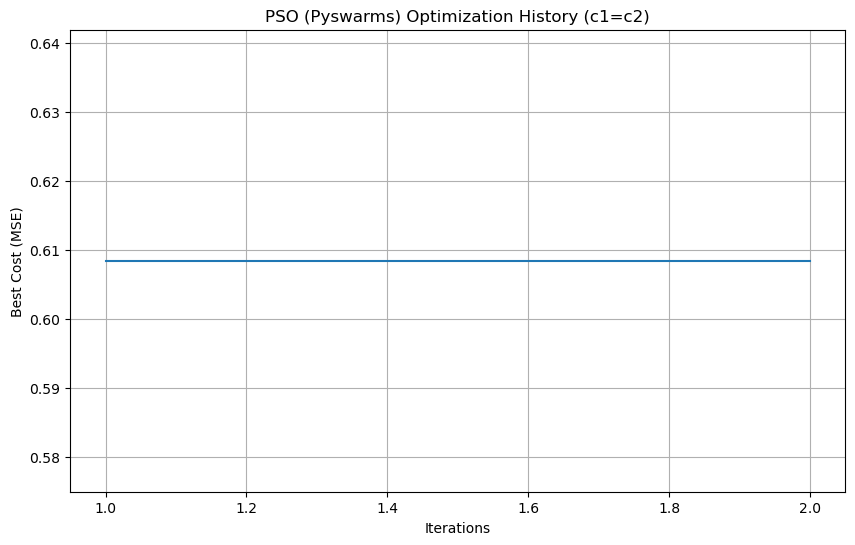

In [71]:
options_c1_eq_c2_Pyswarm = {'c1': 0.7, 'c2': 0.7, 'w': 0.9}

print("Running PSO with c1=c2 ({} iterations)...".format(iters))
best_cost_eq, best_pos_eq, cost_history_eq, mse_pso_eq = run_pso_and_get_history_PSOPyswarms(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_eq_c2_Pyswarm,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="PyswarmsPSO_c1_eq_c2_history.csv"
)

print(f"Final Best Cost (c1=c2): {best_cost_eq:.4f}")
print(f"MSE on Test Set (c1=c2): {mse_pso_eq:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_eq)
plt.title('PSO (Pyswarms) Optimization History (c1=c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


2026-06-08 22:21:59,779 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.5, 'c2': 0.8, 'w': 0.9}


Running PSO with c1<c2 (2 iterations)...


pyswarms.single.global_best: 100%|██████████|2/2, best_cost=0.664
2026-06-08 22:22:09,287 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.6639354773219943, best pos: [12.02956462 12.62016962 12.13158767 12.31766565  1.22633745  0.98397491
  1.10145668  1.54504724  0.33170334  0.79146302  1.97747421  1.34279729
  4.91964896  6.2717244   5.88438638  5.47559915]


Zapisano historię optymalizacji do pliku: PyswarmsPSO_c1_lt_c2_history.csv
Final Best Cost (c1<c2): 0.6639
MSE on Test Set (c1<c2): 0.6214


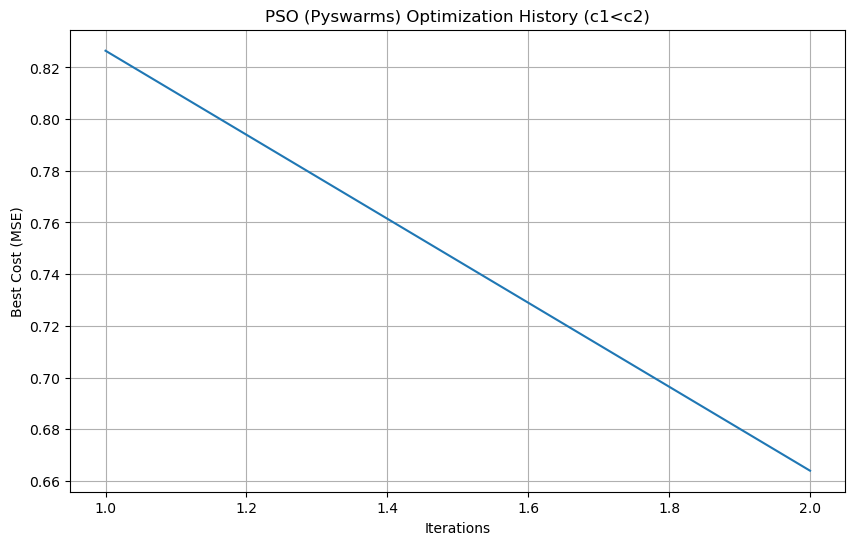

In [72]:
# Configuration for c1 < c2
options_c1_lt_c2_Pyswarm = {'c1': 0.5, 'c2': 0.8, 'w': 0.9}

print("Running PSO with c1<c2 ({} iterations)...".format(iters))
best_cost_lt, best_pos_lt, cost_history_lt, mse_pso_lt = run_pso_and_get_history_PSOPyswarms(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_lt_c2_Pyswarm,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="PyswarmsPSO_c1_lt_c2_history.csv"
)

print(f"Final Best Cost (c1<c2): {best_cost_lt:.4f}")
print(f"MSE on Test Set (c1<c2): {mse_pso_lt:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_lt)
plt.title('PSO (Pyswarms) Optimization History (c1<c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


Running PSO with c1>c2 (2 iterations)...


2026-06-08 22:22:19,839 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.8, 'c2': 0.5, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|2/2, best_cost=0.564
2026-06-08 22:22:30,746 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.5637001467753212, best pos: [12.45479468 10.29633678  9.55185963  9.00892973  0.77314458  0.93609525
  0.25263944  1.54308564  1.23760781  0.46069387  1.75155864  1.39207164
  6.1164392   4.46723425  4.19443977  5.48015884]


Zapisano historię optymalizacji do pliku: PyswarmsPSO_c1_gt_c2_history.csv
Final Best Cost (c1>c2): 0.5637
MSE on Test Set (c1>c2): 0.6551


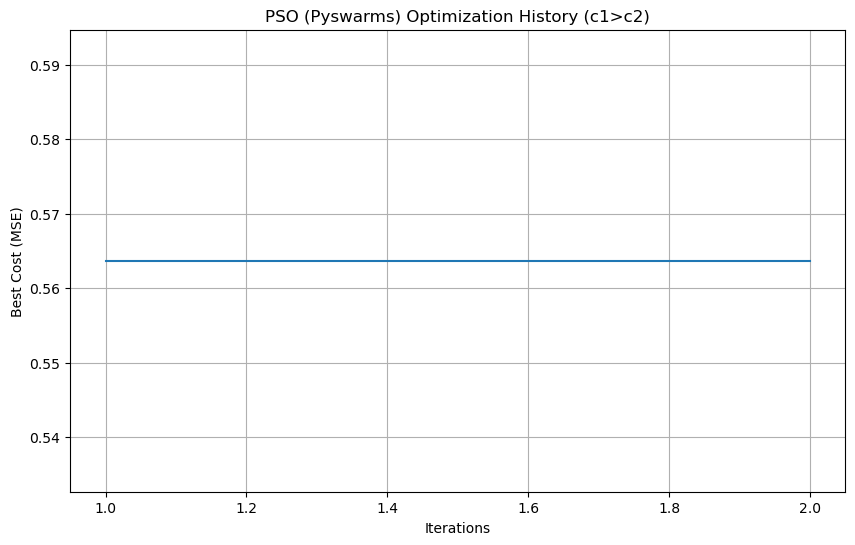

In [73]:
# Configuration for c1 > c2
options_c1_gt_c2_Pyswarm = {'c1': 0.8, 'c2': 0.5, 'w': 0.9}

print("Running PSO with c1>c2 ({} iterations)...".format(iters))
best_cost_gt, best_pos_gt, cost_history_gt, mse_pso_gt = run_pso_and_get_history_PSOPyswarms(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_c1_gt_c2_Pyswarm,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="PyswarmsPSO_c1_gt_c2_history.csv"
)

print(f"Final Best Cost (c1>c2): {best_cost_gt:.4f}")
print(f"MSE on Test Set (c1>c2): {mse_pso_gt:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gt)
plt.title('PSO (Pyswarms) Optimization History (c1>c2)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


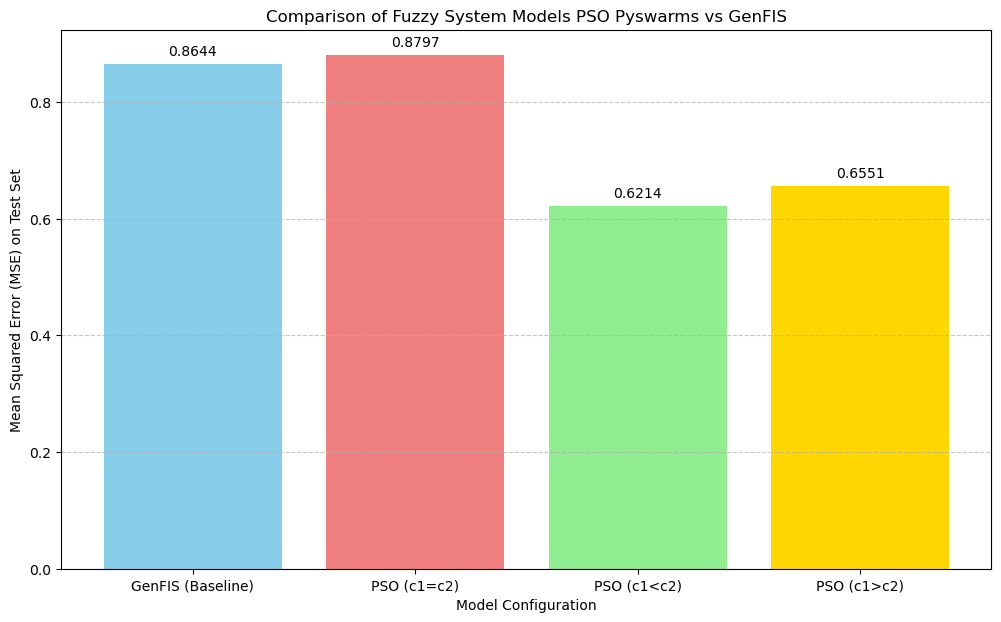

In [74]:
# Data for comparison
model_names = [
    "GenFIS (Baseline)",
    "PSO (c1=c2)",
    "PSO (c1<c2)",
    "PSO (c1>c2)"
]

mse_genfis = evaluate(model_genfis, X_test, y_test)

mse_values = [
    mse_genfis,
    mse_pso_eq,
    mse_pso_lt,
    mse_pso_gt
]

plt.figure(figsize=(12, 7))
plt.bar(model_names, mse_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Model Configuration')
plt.ylabel('Mean Squared Error (MSE) on Test Set')
plt.title('Comparison of Fuzzy System Models PSO Pyswarms vs GenFIS')
plt.ylim(bottom=0) # Ensure y-axis starts from 0

for i, mse in enumerate(mse_values):
    plt.text(i, mse + 0.01, f'{mse:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### PSO TimeTravel with different parameters size

### 8 Params

In [75]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# tsd = ctrl.Antecedent(np.arange(X_reduced_min['total sulfur dioxide'], X_reduced_max['total sulfur dioxide']+0.1, 0.1), 'total sulfur dioxide')

# tsd_dif = X_reduced_max['total sulfur dioxide'] - X_reduced_min['total sulfur dioxide']
# tsd['low'] = fuzz.trapmf(tsd.universe, [X_reduced_min['total sulfur dioxide'],
#                                                X_reduced_min['total sulfur dioxide'],
#                                                X_reduced_min['total sulfur dioxide']+0.2*tsd_dif,
#                                                X_reduced_min['total sulfur dioxide']+0.4*tsd_dif])
# tsd['medium'] = fuzz.trapmf(tsd.universe, [X_reduced_min['total sulfur dioxide']+0.2*tsd_dif,
#                                                   X_reduced_min['total sulfur dioxide']+0.4*tsd_dif,
#                                                   X_reduced_min['total sulfur dioxide']+0.6*tsd_dif,
#                                                   X_reduced_min['total sulfur dioxide']+0.8*tsd_dif])
# tsd['high'] = fuzz.trapmf(tsd.universe, [X_reduced_min['total sulfur dioxide']+0.6*tsd_dif,
#                                                 X_reduced_min['total sulfur dioxide']+0.8*tsd_dif,
#                                                 X_reduced_max['total sulfur dioxide'],
#                                                 X_reduced_max['total sulfur dioxide']])

# tsd.view()

In [76]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# citric_acid = ctrl.Antecedent(np.arange(X_reduced_min['citric acid'], X_reduced_max['citric acid']+0.1, 0.1), 'citric acid')

# citric_acid_dif = X_reduced_max['citric acid'] - X_reduced_min['citric acid']
# citric_acid['low'] = fuzz.trapmf(citric_acid.universe, [X_reduced_min['citric acid'],
#                                                X_reduced_min['citric acid'],
#                                                X_reduced_min['citric acid']+0.2*citric_acid_dif,
#                                                X_reduced_min['citric acid']+0.4*citric_acid_dif])
# citric_acid['medium'] = fuzz.trapmf(citric_acid.universe, [X_reduced_min['citric acid']+0.2*citric_acid_dif,
#                                                   X_reduced_min['citric acid']+0.4*citric_acid_dif,
#                                                   X_reduced_min['citric acid']+0.6*citric_acid_dif,
#                                                   X_reduced_min['citric acid']+0.8*citric_acid_dif])
# citric_acid['high'] = fuzz.trapmf(citric_acid.universe, [X_reduced_min['citric acid']+0.6*citric_acid_dif,
#                                                 X_reduced_min['citric acid']+0.8*citric_acid_dif,
#                                                 X_reduced_max['citric acid'],
#                                                 X_reduced_max['citric acid']])

# citric_acid.view()

In [77]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# density = ctrl.Antecedent(np.arange(X_reduced_min['density'], X_reduced_max['density'], 0.00001), 'density')

# density_dif = X_reduced_max['density'] - X_reduced_min['density']
# density['low'] = fuzz.trapmf(density.universe, [X_reduced_min['density'],
#                                                X_reduced_min['density'],
#                                                X_reduced_min['density']+0.2*density_dif,
#                                                X_reduced_min['density']+0.4*density_dif])
# density['medium'] = fuzz.trapmf(density.universe, [X_reduced_min['density']+0.2*density_dif,
#                                                   X_reduced_min['density']+0.4*density_dif,
#                                                   X_reduced_min['density']+0.6*density_dif,
#                                                   X_reduced_min['density']+0.8*density_dif])
# density['high'] = fuzz.trapmf(density.universe, [X_reduced_min['density']+0.6*density_dif,
#                                                 X_reduced_min['density']+0.8*density_dif,
#                                                 X_reduced_max['density'],
#                                                 X_reduced_max['density']])

# density.view()

In [78]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# fixed_acidity = ctrl.Antecedent(np.arange(X_reduced_min['fixed acidity'], X_reduced_max['fixed acidity']+0.1, 0.1), 'fixed acidity')

# fixed_acidity_dif = X_reduced_max['fixed acidity'] - X_reduced_min['fixed acidity']
# fixed_acidity['low'] = fuzz.trapmf(fixed_acidity.universe, [X_reduced_min['fixed acidity'],
#                                                X_reduced_min['fixed acidity'],
#                                                X_reduced_min['fixed acidity']+0.2*fixed_acidity_dif,
#                                                X_reduced_min['fixed acidity']+0.4*fixed_acidity_dif])
# fixed_acidity['medium'] = fuzz.trapmf(fixed_acidity.universe, [X_reduced_min['fixed acidity']+0.2*fixed_acidity_dif,
#                                                   X_reduced_min['fixed acidity']+0.4*fixed_acidity_dif,
#                                                   X_reduced_min['fixed acidity']+0.6*fixed_acidity_dif,
#                                                   X_reduced_min['fixed acidity']+0.8*fixed_acidity_dif])
# fixed_acidity['high'] = fuzz.trapmf(fixed_acidity.universe, [X_reduced_min['fixed acidity']+0.6*fixed_acidity_dif,
#                                                 X_reduced_min['fixed acidity']+0.8*fixed_acidity_dif,
#                                                 X_reduced_max['fixed acidity'],
#                                                 X_reduced_max['fixed acidity']])

# fixed_acidity.view()

In [79]:
# import itertools
# import numpy as np
# import skfuzzy as fuzz
# from skfuzzy import control as ctrl

# def fuzzy_system_creator_trapmf_8params(parameters):
#     alcohol = ctrl.Antecedent(np.linspace(bounds['alc'][0], bounds['alc'][1], 100), 'alcohol')
#     volatile_acidity = ctrl.Antecedent(np.linspace(bounds['vac'][0], bounds['vac'][1], 100), 'volatile acidity')
#     sulphates = ctrl.Antecedent(np.linspace(bounds['sul'][0], bounds['sul'][1], 100), 'sulphates')
#     total_sulfur_dioxide = ctrl.Antecedent(np.linspace(bounds['tsd'][0], bounds['tsd'][1], 100), 'total sulfur dioxide')
#     citric_acid = ctrl.Antecedent(np.linspace(bounds['cit'][0], bounds['cit'][1], 100), 'citric acid')
#     density = ctrl.Antecedent(np.linspace(bounds['den'][0], bounds['den'][1], 100), 'density')
#     fixed_acidity = ctrl.Antecedent(np.linspace(bounds['fix'][0], bounds['fix'][1], 100), 'fixed acidity')

#     quality = ctrl.Consequent(np.linspace(bounds['qlt'][0], bounds['qlt'][1], 100), 'quality')

#     p = np.sort(parameters[0:4])
#     alcohol['low'] = fuzz.trapmf(alcohol.universe, [bounds['alc'][0], bounds['alc'][0], p[0], p[1]])
#     alcohol['medium'] = fuzz.trapmf(alcohol.universe, [p[0], p[1], p[2], p[3]])
#     alcohol['high'] = fuzz.trapmf(alcohol.universe, [p[2], p[3], bounds['alc'][1], bounds['alc'][1]])

#     p = np.sort(parameters[4:8])
#     volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [bounds['vac'][0], bounds['vac'][0], p[0], p[1]])
#     volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [p[0], p[1], p[2], p[3]])
#     volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [p[2], p[3], bounds['vac'][1], bounds['vac'][1]])

#     p = np.sort(parameters[8:12])
#     sulphates['low'] = fuzz.trapmf(sulphates.universe, [bounds['sul'][0], bounds['sul'][0], p[0], p[1]])
#     sulphates['medium'] = fuzz.trapmf(sulphates.universe, [p[0], p[1], p[2], p[3]])
#     sulphates['high'] = fuzz.trapmf(sulphates.universe, [p[2], p[3], bounds['sul'][1], bounds['sul'][1]])

#     p = np.sort(parameters[12:16])
#     total_sulfur_dioxide['low'] = fuzz.trapmf(total_sulfur_dioxide.universe, [bounds['tsd'][0], bounds['tsd'][0], p[0], p[1]])
#     total_sulfur_dioxide['medium'] = fuzz.trapmf(total_sulfur_dioxide.universe, [p[0], p[1], p[2], p[3]])
#     total_sulfur_dioxide['high'] = fuzz.trapmf(total_sulfur_dioxide.universe, [p[2], p[3], bounds['tsd'][1], bounds['tsd'][1]])

#     p = np.sort(parameters[16:20])
#     citric_acid['low'] = fuzz.trapmf(citric_acid.universe, [bounds['cit'][0], bounds['cit'][0], p[0], p[1]])
#     citric_acid['medium'] = fuzz.trapmf(citric_acid.universe, [p[0], p[1], p[2], p[3]])
#     citric_acid['high'] = fuzz.trapmf(citric_acid.universe, [p[2], p[3], bounds['cit'][1], bounds['cit'][1]])

#     p = np.sort(parameters[20:24])
#     density['low'] = fuzz.trapmf(density.universe, [bounds['den'][0], bounds['den'][0], p[0], p[1]])
#     density['medium'] = fuzz.trapmf(density.universe, [p[0], p[1], p[2], p[3]])
#     density['high'] = fuzz.trapmf(density.universe, [p[2], p[3], bounds['den'][1], bounds['den'][1]])

#     p = np.sort(parameters[24:28])
#     fixed_acidity['low'] = fuzz.trapmf(fixed_acidity.universe, [bounds['fix'][0], bounds['fix'][0], p[0], p[1]])
#     fixed_acidity['medium'] = fuzz.trapmf(fixed_acidity.universe, [p[0], p[1], p[2], p[3]])
#     fixed_acidity['high'] = fuzz.trapmf(fixed_acidity.universe, [p[2], p[3], bounds['fix'][1], bounds['fix'][1]])

#     p = np.sort(parameters[28:32])
#     quality['poor'] = fuzz.trapmf(quality.universe, [bounds['qlt'][0], bounds['qlt'][0], p[0], p[1]])
#     quality['average'] = fuzz.trapmf(quality.universe, [p[0], p[1], p[2], p[3]])
#     quality['good'] = fuzz.trapmf(quality.universe, [p[2], p[3], bounds['qlt'][1], bounds['qlt'][1]])

#     waga_input = {
#         'alcohol': {'low': 1, 'medium': 2+1, 'high': 3+1},
#         'volatile_acidity': {'low': 3+1, 'medium': 2+1, 'high': 1},
#         'sulphates': {'low': 1, 'medium': 2, 'high': 3},
#         'total_sulfur_dioxide': {'low': 3, 'medium': 2, 'high': 1},
#         'citric_acid': {'low': 1, 'medium': 2, 'high': 3},
#         'density': {'low': 3, 'medium': 2, 'high': 1},
#         'fixed_acidity': {'low': 1, 'medium': 2-1, 'high': 3-1}
#     }

#     rules = []

#     for alc, vac, sul, tsd, cit, den, fix in itertools.product(['low', 'medium', 'high'], repeat=7):
#         score = (waga_input['alcohol'][alc] +
#                  waga_input['volatile_acidity'][vac] +
#                  waga_input['sulphates'][sul] +
#                  waga_input['total_sulfur_dioxide'][tsd] +
#                  waga_input['citric_acid'][cit] +
#                  waga_input['density'][den] +
#                  waga_input['fixed_acidity'][fix])

#         if score <= 13:
#             out_quality = 'poor'
#         elif score >= 19:
#             out_quality = 'good'
#         else:
#             out_quality = 'average'

#         rule = ctrl.Rule(
#             alcohol[alc] &
#             volatile_acidity[vac] &
#             sulphates[sul] &
#             total_sulfur_dioxide[tsd] &
#             citric_acid[cit] &
#             density[den] &
#             fixed_acidity[fix],
#             quality[out_quality]
#         )
#         rules.append(rule)

#     control_system = ctrl.ControlSystem(rules)
#     model = ctrl.ControlSystemSimulation(control_system)

#     return model, alcohol, volatile_acidity, sulphates, total_sulfur_dioxide, citric_acid, density, fixed_acidity, quality

In [80]:
# def fitness_function_8params(swarm_params):
#     n_particles = swarm_params.shape[0]
#     results = []

#     # Dla przyspieszenia obliczeń w PSO używamy podzbioru danych treningowych
#     X_sub_np = X_train[:50].values # Convert X_sub to a numpy array for robust iteration
#     y_sub_flat = y_train[:50].values.flatten() # Convert y_sub to a 1D numpy array

#     default_prediction = y_sub_flat.mean()

#     for i in range(n_particles):
#         try:
#             # Correctly unpack the tuple returned by fuzzy_system_creator_trapmf
#             sim_model, _, _, _, _ = fuzzy_system_creator_trapmf_8params(swarm_params[i])

#             preds_particle = np.full(len(X_sub_np), default_prediction) # Initialize predictions for current particle

#             for j, val in enumerate(X_sub_np):
#                 try:
#                     sim_model.input['alcohol'] = val[0]
#                     sim_model.input['volatile acidity'] = val[1]
#                     sim_model.input['sulphates'] = val[2]
#                     sim_model.input['total sulfur dioxide'] = val[3]
#                     sim_model.input['citric acid'] = val[4]
#                     sim_model.input['density'] = val[5]
#                     sim_model.input['fixed acidity'] = val[6]
#                     sim_model.compute()
#                     preds_particle[j] = sim_model.output['quality']
#                 except:
#                     # If computation fails for a specific input, the default_prediction
#                     # for this index in 'preds_particle' will remain.
#                     pass

#             # Both y_sub_flat and preds_particle are now 1D numpy arrays of the same length
#             results.append(mean_squared_error(y_sub_flat, preds_particle))
#         except Exception as e:
#             # This outer except block catches errors during fuzzy system creation itself
#             # or other unexpected issues before prediction calculation.
#             results.append(100.0) # Penalty for a failed fuzzy system

#     return np.array(results)

In [81]:
# def evaluate_8params(model, X, y):
#     # Initialize predictions with a default value (e.g., mean of y_true)
#     # This ensures `preds` always has the same length as `y`.
#     default_prediction = np.mean(y)
#     preds = np.full(len(X), default_prediction)

#     for i, val in enumerate(X.values):
#         try:
#             model.input['alcohol'] = val[0]
#             model.input['volatile acidity'] = val[1]
#             model.input['sulphates'] = val[2]
#             model.input['total sulfur dioxide'] = val[3]
#             model.input['citric acid'] = val[4]
#             model.input['density'] = val[5]
#             model.input['fixed acidity'] = val[6]
#             model.compute()
#             # model.input['alcohol'] = val[0]
#             # model.input['volatile acidity'] = val[1]
#             # model.input['sulphates'] = val[2]
#             # model.compute()
#             preds[i] = model.output['quality']
#         except:
#             # If computation fails for this specific input, the default_prediction
#             # for this index in 'preds' will remain.
#             pass # The default value in preds will be used for this entry.
#     return mean_squared_error(y, preds)

In [82]:
# import pyswarms as ps
# import matplotlib.pyplot as plt

# def run_pso_and_get_history_TimeTravelPSO_8params(n_particles, dimensions, iters, options, pso_bounds, fitness_function, X_test, y_test, csv_filename=None):
#     """
#     Runs PSO optimization, collects cost history, and evaluates the best model on the test set.

#     Args:
#         n_particles (int): Number of particles in the swarm.
#         dimensions (int): Number of dimensions (parameters) to optimize.
#         iters (int): Number of iterations for the optimizer.
#         options (dict): Dictionary of PSO options (c1, c2, w).
#         pso_bounds (tuple): Tuple of (min_bound, max_bound) for the search space.
#         fitness_function (function): The fitness function to optimize.
#         X_test (pd.DataFrame): Test feature data.
#         y_test (pd.DataFrame): Test target data.

#     Returns:
#         tuple: (final_best_cost, best_position, cost_history, mse_on_test_set)
#     """
#     # optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
#     # best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

#     optimizer = TimeTravelPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
#     best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

#     cost_history = optimizer.cost_history

#     # Eksport historii do CSV
#     if csv_filename:
#         df_hist = pd.DataFrame({
#             'Iteracja': range(1, len(cost_history) + 1),
#             'MSE': cost_history
#         })
#         df_hist.to_csv(csv_filename, index=False)
#         print(f"Zapisano historię optymalizacji do pliku: {csv_filename}")

#     # Evaluate the best found position on the test set
#     # fuzzy_system_creator_trapmf returns a tuple, we need only the model (first element)
#     sim_model_best_pso, _, _, _, _ = fuzzy_system_creator_trapmf_8params(best_pos)
#     mse_on_test_set = evaluate_8params(sim_model_best_pso, X_test, y_test)

#     return best_cost, best_pos, cost_history, mse_on_test_set


In [83]:
# import numpy as np

# # Zakresy poszukiwań dla PSO (znormalizowane do zakresów zmiennych)
# min_bound_8params = np.array([bounds['alc'][0]]*4 + 
#                              [bounds['vac'][0]]*4 + 
#                              [bounds['sul'][0]]*4 + 
#                              [bounds['tsd'][0]]*4 +
#                              [bounds['cit'][0]]*4 +
#                              [bounds['den'][0]]*4 +
#                              [bounds['fix'][0]]*4 +
#                              [bounds['qlt'][0]]*4) # Corrected bounds['sul'][1] to bounds['sul'][0]
# max_bound_8params = np.array([bounds['alc'][1]]*4 + 
#                              [bounds['vac'][1]]*4 + 
#                              [bounds['sul'][1]]*4 + 
#                              [bounds['tsd'][1]]*4 +
#                              [bounds['cit'][1]]*4 +
#                              [bounds['den'][1]]*4 +
#                              [bounds['fix'][1]]*4 +
#                              [bounds['qlt'][1]]*4) # Corrected bounds['sul'][0] to bounds['sul'][1]
# pso_bounds_8params = (min_bound_8params, max_bound_8params)

# def generate_initial_trapmf_8params(bounds):
#     """
#     Generates initial parameters for trapezoidal membership functions.
#     These parameters are structured for use with fuzzy_system_creator_trapmf,
#     ensuring the 'a <= b <= c <= d' condition for trapezoids.

#     Args:
#         bounds (dict): A dictionary containing min/max bounds for each variable
#                        ('alc', 'vac', 'sul', 'qlt', 'tsd', 'cit', 'den', 'fix').

#     Returns:
#         np.array: A 1D numpy array of 32 parameters (4 for each of 8 variables).
#     """
#     min_bound, max_bound = bounds
#     all_params = []
#     # Order of variables as expected by fuzzy_system_creator_trapmf
#     variable_keys = ['alc', 'vac', 'sul', 'tsd', 'cit', 'den', 'fix', 'qlt']

#     # These points define the 'shoulders' and 'feet' of the trapezoidal MFs.
#     # The fuzzy_system_creator_trapmf function uses these points to define:
#     # 'low':    [min, min, p[0], p[1]]
#     # 'medium': [p[0], p[1], p[2], p[3]]
#     # 'high':   [p[2], p[3], max, max]
#     # We ensure p[0] <= p[1] <= p[2] <= p[3] and they are within [min, max].

#     # Using quartiles of the range for a reasonable initial spread.
#     # These percentages can be adjusted for different initial distributions.
#     relative_points = [0.20, 0.40, 0.60, 0.80]

#     # for key in variable_keys:
#     #     min_val, max_val = bounds[key]
#     #     value_range = max_val - min_val

#     #     # Calculate the 4 points for the current variable
#     #     p0 = min_val + (value_range * relative_points[0])
#     #     p1 = min_val + (value_range * relative_points[1])
#     #     p2 = min_val + (value_range * relative_points[2])
#     #     p3 = min_val + (value_range * relative_points[3])

#     #     current_var_params = [p0, p1, p2, p3]
#     #     all_params.extend(current_var_params)
#     for idx, key in enumerate(variable_keys):
#         # Ponieważ min_bound i max_bound pakują po 4 elementy dla każdej zmiennej:
#         # alc: 0-3, vac: 4-7, sul: 8-11, qlt: 12-15
#         start_idx = idx * 4
#         min_val = min_bound[start_idx]
#         max_val = max_bound[start_idx]
#         value_range = max_val - min_val

#         # Calculate the 4 points for the current variable
#         p0 = min_val + (value_range * relative_points[0])
#         p1 = min_val + (value_range * relative_points[1])
#         p2 = min_val + (value_range * relative_points[2])
#         p3 = min_val + (value_range * relative_points[3])
        
#         current_var_params = [p0, p1, p2, p3]
#         all_params.extend(current_var_params)

#     return np.array(all_params)

# def genfis_trapmf_matlab_like_8params(bounds):
#     """
#     Generates an initial fuzzy inference system (FIS) using trapezoidal membership functions,
#     similar to how 'genfis' might initialize a system in MATLAB for grid partitioning.

#     Args:
#         bounds (dict): A dictionary containing min/max bounds for each variable
#                        ('alc', 'vac', 'sul', 'qlt', 'tsd', 'cit', 'den', 'fix').

#     Returns:
#         tuple: A tuple containing the control system simulation object, and the
#                antecedent/consequent fuzzy variables (alcohol, volatile_acidity,
#                sulphates, quality).
#     """
#     initial_params = generate_initial_trapmf_8params(bounds)
#     return fuzzy_system_creator_trapmf_8params(initial_params)

# # Now, use this function to create the model
# print('Creating initial fuzzy system using genfis_trapmf_matlab_like_8params...')
# model_genfis, alc_genfis, vac_genfis, sul_genfis, tsd_genfis, cit_genfis, den_genfis, fix_genfis, qlt_genfis = genfis_trapmf_matlab_like_8params(pso_bounds_8params)
# print('Initial fuzzy system created successfully using genfis_trapmf_matlab_like_8params.')

# # Optionally, view the generated membership functions
# alc_genfis.view()
# vac_genfis.view()
# sul_genfis.view()
# qlt_genfis.view()
# tsd_genfis.view()
# cit_genfis.view()
# den_genfis.view()
# fix_genfis.view()

In [84]:
# options_c1_eq_c2_8params = {'c1': 0.7, 'c2': 0.7, 'w': 0.9}
# dimensions_8params = 8 * 4 # Number of parameters for trapezoidal MFs

# print("Running PSO with c1=c2 ({} iterations)...".format(iters))
# best_cost_eq, best_pos_eq, cost_history_eq, mse_pso_eq = run_pso_and_get_history_TimeTravelPSO_8params(
#     n_particles=n_particles,
#     dimensions=dimensions_8params,
#     iters=iters,
#     options=options_c1_eq_c2_8params,
#     pso_bounds=pso_bounds_8params,
#     fitness_function=fitness_function_8params,
#     X_test=X_test,
#     y_test=y_test,
#     csv_filename="TimeTravelPSO_c1_eq_c2_8params_history.csv"
# )

# print(f"Final Best Cost (c1=c2): {best_cost_eq:.4f}")
# print(f"MSE on Test Set (c1=c2): {mse_pso_eq:.4f}")

# # Plot the cost history
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, iters + 1), cost_history_eq)
# plt.title('PSO (TimeTravel) Optimization History 8 params (c1=c2)')
# plt.xlabel('Iterations')
# plt.ylabel('Best Cost (MSE)')
# plt.grid(True)
# plt.show()


In [85]:
# options_c1_gt_c2_8params = {'c1': 0.8, 'c2': 0.5, 'w': 0.9}

# print("Running PSO with c1>c2 ({} iterations)...".format(iters))
# best_cost_gt, best_pos_gt, cost_history_gt, mse_pso_gt = run_pso_and_get_history_TimeTravelPSO_8params(
#     n_particles=n_particles,
#     dimensions=dimensions_8params,
#     iters=iters,
#     options=options_c1_gt_c2_8params,
#     pso_bounds=pso_bounds_8params,
#     fitness_function=fitness_function_8params,
#     X_test=X_test,
#     y_test=y_test,
#     csv_filename="TimeTravelPSO_c1_gt_c2_8params_history.csv"
# )

# print(f"Final Best Cost (c1>c2): {best_cost_gt:.4f}")
# print(f"MSE on Test Set (c1>c2): {mse_pso_gt:.4f}")

# # Plot the cost history
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, iters + 1), cost_history_gt)
# plt.title('PSO (TimeTravel) Optimization History 8 params (c1>c2)')
# plt.xlabel('Iterations')
# plt.ylabel('Best Cost (MSE)')
# plt.grid(True)
# plt.show()


In [86]:
# options_c1_lt_c2_8params = {'c1': 0.5, 'c2': 0.8, 'w': 0.9}

# print("Running PSO with c1<c2 ({} iterations)...".format(iters))
# best_cost_lt, best_pos_lt, cost_history_lt, mse_pso_lt = run_pso_and_get_history_TimeTravelPSO_8params(
#     n_particles=n_particles,
#     dimensions=dimensions_8params,
#     iters=iters,
#     options=options_c1_lt_c2_8params,
#     pso_bounds=pso_bounds_8params,
#     fitness_function=fitness_function_8params,
#     X_test=X_test,
#     y_test=y_test,
#     csv_filename="TimeTravelPSO_c1_lt_c2_8params_history.csv"
# )

# print(f"Final Best Cost (c1<c2): {best_cost_lt:.4f}")
# print(f"MSE on Test Set (c1<c2): {mse_pso_lt:.4f}")

# # Plot the cost history
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, iters + 1), cost_history_lt)
# plt.title('PSO (TimeTravel) Optimization History 8 params (c1<c2)')
# plt.xlabel('Iterations')
# plt.ylabel('Best Cost (MSE)')
# plt.grid(True)
# plt.show()


In [87]:
# # Data for comparison
# model_names = [
#     "GenFIS (Baseline)",
#     "PSO (c1=c2)",
#     "PSO (c1<c2)",
#     "PSO (c1>c2)"
# ]

# mse_genfis = evaluate(model_genfis, X_test, y_test)

# mse_values = [
#     mse_genfis,
#     mse_pso_eq,
#     mse_pso_lt,
#     mse_pso_gt
# ]

# plt.figure(figsize=(12, 7))
# plt.bar(model_names, mse_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
# plt.xlabel('Model Configuration')
# plt.ylabel('Mean Squared Error (MSE) on Test Set')
# plt.title('Comparison of Fuzzy System Models PSO TimeTravel (8 params) vs GenFIS')
# plt.ylim(bottom=0) # Ensure y-axis starts from 0

# for i, mse in enumerate(mse_values):
#     plt.text(i, mse + 0.01, f'{mse:.4f}', ha='center', va='bottom')

# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()


### 12 Params

In [88]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# chlorides = ctrl.Antecedent(np.arange(X_reduced_min['chlorides'], X_reduced_max['chlorides']+0.001, 0.001), 'chlorides')

# chlorides_dif = X_reduced_max['chlorides'] - X_reduced_min['chlorides']
# chlorides['low'] = fuzz.trapmf(chlorides.universe, [X_reduced_min['chlorides'],
#                                                X_reduced_min['chlorides'],
#                                                X_reduced_min['chlorides']+0.2*chlorides_dif,
#                                                X_reduced_min['chlorides']+0.4*chlorides_dif])
# chlorides['medium'] = fuzz.trapmf(chlorides.universe, [X_reduced_min['chlorides']+0.2*chlorides_dif,
#                                                   X_reduced_min['chlorides']+0.4*chlorides_dif,
#                                                   X_reduced_min['chlorides']+0.6*chlorides_dif,
#                                                   X_reduced_min['chlorides']+0.8*chlorides_dif])
# chlorides['high'] = fuzz.trapmf(chlorides.universe, [X_reduced_min['chlorides']+0.6*chlorides_dif,
#                                                 X_reduced_min['chlorides']+0.8*chlorides_dif,
#                                                 X_reduced_max['chlorides'],
#                                                 X_reduced_max['chlorides']])

# chlorides.view()

In [89]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# residual_sugar = ctrl.Antecedent(np.arange(X_reduced_min['residual sugar'], X_reduced_max['residual sugar'], 0.1), 'residual sugar')

# residual_sugar_dif = X_reduced_max['residual sugar'] - X_reduced_min['residual sugar']
# residual_sugar['low'] = fuzz.trapmf(residual_sugar.universe, [X_reduced_min['residual sugar'],
#                                                X_reduced_min['residual sugar'],
#                                                X_reduced_min['residual sugar']+0.2*residual_sugar_dif,
#                                                X_reduced_min['residual sugar']+0.4*residual_sugar_dif])
# residual_sugar['medium'] = fuzz.trapmf(residual_sugar.universe, [X_reduced_min['residual sugar']+0.2*residual_sugar_dif,
#                                                   X_reduced_min['residual sugar']+0.4*residual_sugar_dif,
#                                                   X_reduced_min['residual sugar']+0.6*residual_sugar_dif,
#                                                   X_reduced_min['residual sugar']+0.8*residual_sugar_dif])
# residual_sugar['high'] = fuzz.trapmf(residual_sugar.universe, [X_reduced_min['residual sugar']+0.6*residual_sugar_dif,
#                                                 X_reduced_min['residual sugar']+0.8*residual_sugar_dif,
#                                                 X_reduced_max['residual sugar'],
#                                                 X_reduced_max['residual sugar']])

# residual_sugar.view()

In [90]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# pH = ctrl.Antecedent(np.arange(X_reduced_min['pH'], X_reduced_max['pH'], 0.01), 'pH')

# pH_dif = X_reduced_max['pH'] - X_reduced_min['pH']
# pH['low'] = fuzz.trapmf(pH.universe, [X_reduced_min['pH'],
#                                                X_reduced_min['pH'],
#                                                X_reduced_min['pH']+0.2*pH_dif,
#                                                X_reduced_min['pH']+0.4*pH_dif])
# pH['medium'] = fuzz.trapmf(pH.universe, [X_reduced_min['pH']+0.2*pH_dif,
#                                                   X_reduced_min['pH']+0.4*pH_dif,
#                                                   X_reduced_min['pH']+0.6*pH_dif,
#                                                   X_reduced_min['pH']+0.8*pH_dif])
# pH['high'] = fuzz.trapmf(pH.universe, [X_reduced_min['pH']+0.6*pH_dif,
#                                                 X_reduced_min['pH']+0.8*pH_dif,
#                                                 X_reduced_max['pH'],
#                                                 X_reduced_max['pH']])

# pH.view()

In [91]:
# from skfuzzy import control as ctrl
# import skfuzzy as fuzz
# fsd = ctrl.Antecedent(np.arange(X_reduced_min['free sulfur dioxide'], X_reduced_max['free sulfur dioxide'], 0.1), 'free sulfur dioxide')

# fsd_dif = X_reduced_max['free sulfur dioxide'] - X_reduced_min['free sulfur dioxide']
# fsd['low'] = fuzz.trapmf(fsd.universe, [X_reduced_min['free sulfur dioxide'],
#                                                X_reduced_min['free sulfur dioxide'],
#                                                X_reduced_min['free sulfur dioxide']+0.2*fsd_dif,
#                                                X_reduced_min['free sulfur dioxide']+0.4*fsd_dif])
# fsd['medium'] = fuzz.trapmf(fsd.universe, [X_reduced_min['free sulfur dioxide']+0.2*fsd_dif,
#                                                   X_reduced_min['free sulfur dioxide']+0.4*fsd_dif,
#                                                   X_reduced_min['free sulfur dioxide']+0.6*fsd_dif,
#                                                   X_reduced_min['free sulfur dioxide']+0.8*fsd_dif])
# fsd['high'] = fuzz.trapmf(fsd.universe, [X_reduced_min['free sulfur dioxide']+0.6*fsd_dif,
#                                                 X_reduced_min['free sulfur dioxide']+0.8*fsd_dif,
#                                                 X_reduced_max['free sulfur dioxide'],
#                                                 X_reduced_max['free sulfur dioxide']])

# fsd.view()

In [92]:
# import itertools
# import numpy as np
# import skfuzzy as fuzz
# from skfuzzy import control as ctrl

# def fuzzy_system_creator_trapmf_12params(parameters):
#     alcohol = ctrl.Antecedent(np.linspace(bounds['alc'][0], bounds['alc'][1], 100), 'alcohol')
#     volatile_acidity = ctrl.Antecedent(np.linspace(bounds['vac'][0], bounds['vac'][1], 100), 'volatile acidity')
#     sulphates = ctrl.Antecedent(np.linspace(bounds['sul'][0], bounds['sul'][1], 100), 'sulphates')
#     citric_acid = ctrl.Antecedent(np.linspace(bounds['cit'][0], bounds['cit'][1], 100), 'citric acid')
#     fixed_acidity = ctrl.Antecedent(np.linspace(bounds['fix'][0], bounds['fix'][1], 100), 'fixed acidity')
#     residual_sugar = ctrl.Antecedent(np.linspace(bounds['res'][0], bounds['res'][1], 100), 'residual sugar')
#     free_sulfur_dioxide = ctrl.Antecedent(np.linspace(bounds['fsod'][0], bounds['fsod'][1], 100), 'free sulfur dioxide')
#     pH = ctrl.Antecedent(np.linspace(bounds['ph'][0], bounds['ph'][1], 100), 'pH')
#     chlorides = ctrl.Antecedent(np.linspace(bounds['chl'][0], bounds['chl'][1], 100), 'chlorides')
#     density = ctrl.Antecedent(np.linspace(bounds['den'][0], bounds['den'][1], 100), 'density')
#     total_sulfur_dioxide = ctrl.Antecedent(np.linspace(bounds['tsd'][0], bounds['tsd'][1], 100), 'total sulfur dioxide')

#     quality = ctrl.Consequent(np.linspace(bounds['qlt'][0], bounds['qlt'][1], 100), 'quality')

#     p = np.sort(parameters[0:4])
#     alcohol['low'] = fuzz.trapmf(alcohol.universe, [bounds['alc'][0], bounds['alc'][0], p[0], p[1]])
#     alcohol['medium'] = fuzz.trapmf(alcohol.universe, [p[0], p[1], p[2], p[3]])
#     alcohol['high'] = fuzz.trapmf(alcohol.universe, [p[2], p[3], bounds['alc'][1], bounds['alc'][1]])

#     p = np.sort(parameters[4:8])
#     volatile_acidity['low'] = fuzz.trapmf(volatile_acidity.universe, [bounds['vac'][0], bounds['vac'][0], p[0], p[1]])
#     volatile_acidity['medium'] = fuzz.trapmf(volatile_acidity.universe, [p[0], p[1], p[2], p[3]])
#     volatile_acidity['high'] = fuzz.trapmf(volatile_acidity.universe, [p[2], p[3], bounds['vac'][1], bounds['vac'][1]])

#     p = np.sort(parameters[8:12])
#     sulphates['low'] = fuzz.trapmf(sulphates.universe, [bounds['sul'][0], bounds['sul'][0], p[0], p[1]])
#     sulphates['medium'] = fuzz.trapmf(sulphates.universe, [p[0], p[1], p[2], p[3]])
#     sulphates['high'] = fuzz.trapmf(sulphates.universe, [p[2], p[3], bounds['sul'][1], bounds['sul'][1]])
    
#     p = np.sort(parameters[12:16])
#     total_sulfur_dioxide['low'] = fuzz.trapmf(total_sulfur_dioxide.universe, [bounds['tsd'][0], bounds['tsd'][0], p[0], p[1]])
#     total_sulfur_dioxide['medium'] = fuzz.trapmf(total_sulfur_dioxide.universe, [p[0], p[1], p[2], p[3]])
#     total_sulfur_dioxide['high'] = fuzz.trapmf(total_sulfur_dioxide.universe, [p[2], p[3], bounds['tsd'][1], bounds['tsd'][1]])

#     p = np.sort(parameters[16:20])
#     citric_acid['low'] = fuzz.trapmf(citric_acid.universe, [bounds['cit'][0], bounds['cit'][0], p[0], p[1]])
#     citric_acid['medium'] = fuzz.trapmf(citric_acid.universe, [p[0], p[1], p[2], p[3]])
#     citric_acid['high'] = fuzz.trapmf(citric_acid.universe, [p[2], p[3], bounds['cit'][1], bounds['cit'][1]])
    
#     p = np.sort(parameters[20:24])
#     density['low'] = fuzz.trapmf(density.universe, [bounds['den'][0], bounds['den'][0], p[0], p[1]])
#     density['medium'] = fuzz.trapmf(density.universe, [p[0], p[1], p[2], p[3]])
#     density['high'] = fuzz.trapmf(density.universe, [p[2], p[3], bounds['den'][1], bounds['den'][1]])

#     p = np.sort(parameters[24:28])
#     fixed_acidity['low'] = fuzz.trapmf(fixed_acidity.universe, [bounds['fix'][0], bounds['fix'][0], p[0], p[1]])
#     fixed_acidity['medium'] = fuzz.trapmf(fixed_acidity.universe, [p[0], p[1], p[2], p[3]])
#     fixed_acidity['high'] = fuzz.trapmf(fixed_acidity.universe, [p[2], p[3], bounds['fix'][1], bounds['fix'][1]])

#     p = np.sort(parameters[28:32])
#     residual_sugar['low'] = fuzz.trapmf(residual_sugar.universe, [bounds['sug'][0], bounds['sug'][0], p[0], p[1]])
#     residual_sugar['medium'] = fuzz.trapmf(residual_sugar.universe, [p[0], p[1], p[2], p[3]])
#     residual_sugar['high'] = fuzz.trapmf(residual_sugar.universe, [p[2], p[3], bounds['sug'][1], bounds['sug'][1]])

#     p = np.sort(parameters[32:36])
#     free_sulfur_dioxide['low'] = fuzz.trapmf(free_sulfur_dioxide.universe, [bounds['fsd'][0], bounds['fsd'][0], p[0], p[1]])
#     free_sulfur_dioxide['medium'] = fuzz.trapmf(free_sulfur_dioxide.universe, [p[0], p[1], p[2], p[3]])
#     free_sulfur_dioxide['high'] = fuzz.trapmf(free_sulfur_dioxide.universe, [p[2], p[3], bounds['fsd'][1], bounds['fsd'][1]])

#     p = np.sort(parameters[36:40])
#     pH['low'] = fuzz.trapmf(pH.universe, [bounds['ph'][0], bounds['ph'][0], p[0], p[1]])
#     pH['medium'] = fuzz.trapmf(pH.universe, [p[0], p[1], p[2], p[3]])
#     pH['high'] = fuzz.trapmf(pH.universe, [p[2], p[3], bounds['ph'][1], bounds['ph'][1]])

#     p = np.sort(parameters[40:44])
#     chlorides['low'] = fuzz.trapmf(chlorides.universe, [bounds['chl'][0], bounds['chl'][0], p[0], p[1]])
#     chlorides['medium'] = fuzz.trapmf(chlorides.universe, [p[0], p[1], p[2], p[3]])
#     chlorides['high'] = fuzz.trapmf(chlorides.universe, [p[2], p[3], bounds['chl'][1], bounds['chl'][1]])
    

#     p = np.sort(parameters[44:48])
#     quality['poor'] = fuzz.trapmf(quality.universe, [bounds['qlt'][0], bounds['qlt'][0], p[0], p[1]])
#     quality['average'] = fuzz.trapmf(quality.universe, [p[0], p[1], p[2], p[3]])
#     quality['good'] = fuzz.trapmf(quality.universe, [p[2], p[3], bounds['qlt'][1], bounds['qlt'][1]])

#     waga_input = {
#         'alcohol': {'low': 1, 'medium': 2+1, 'high': 3+1},
#         'volatile_acidity': {'low': 3+1, 'medium': 2+1, 'high': 1},
#         'sulphates': {'low': 1, 'medium': 2, 'high': 3},
#         'citric_acid': {'low': 1, 'medium': 2, 'high': 3},
#         'fixed_acidity': {'low': 1, 'medium': 2, 'high': 3},
#         'residual_sugar': {'low': 1, 'medium': 2-1, 'high': 3-1},
#         'free_sulfur_dioxide': {'low': 3-1, 'medium': 2-1, 'high': 1},
#         'pH': {'low': 3-1, 'medium': 2-1, 'high': 1},
#         'chlorides': {'low': 3, 'medium': 2, 'high': 1},
#         'density': {'low': 3, 'medium': 2, 'high': 1},
#         'total_sulfur_dioxide': {'low': 3, 'medium': 2, 'high': 1}
#     }

#     rules = []

#     for alc, vac, sul, cit, fix, sug, fsd, ph, chl, den, tsd in itertools.product(['low', 'medium', 'high'], repeat=11):
#         score = (waga_input['alcohol'][alc] +
#                  waga_input['volatile_acidity'][vac] +
#                  waga_input['sulphates'][sul] +
#                  waga_input['citric_acid'][cit] +
#                  waga_input['fixed_acidity'][fix] +
#                  waga_input['residual_sugar'][sug] +
#                  waga_input['free_sulfur_dioxide'][fsd] +
#                  waga_input['pH'][ph] +
#                  waga_input['chlorides'][chl] +
#                  waga_input['density'][den] +
#                  waga_input['total_sulfur_dioxide'][tsd])

#         if score <= 21:
#             out_quality = 'poor'
#         elif score >= 31:
#             out_quality = 'good'
#         else:
#             out_quality = 'average'

#         rule = ctrl.Rule(
#             alcohol[alc] &
#             volatile_acidity[vac] &
#             sulphates[sul] &
#             citric_acid[cit] &
#             fixed_acidity[fix] &
#             residual_sugar[sug] &
#             free_sulfur_dioxide[fsd] &
#             pH[ph] &
#             chlorides[chl] &
#             density[den] &
#             total_sulfur_dioxide[tsd],
#             quality[out_quality]
#         )
#         rules.append(rule)

#     control_system = ctrl.ControlSystem(rules)
#     model = ctrl.ControlSystemSimulation(control_system)

#     return model, alcohol, volatile_acidity, sulphates, citric_acid, fixed_acidity, residual_sugar, free_sulfur_dioxide, pH, chlorides, density, total_sulfur_dioxide, quality

In [93]:
# def fitness_function_12params(swarm_params):
#     n_particles = swarm_params.shape[0]
#     results = []

#     # Dla przyspieszenia obliczeń w PSO używamy podzbioru danych treningowych
#     X_sub_np = X_train[:50].values # Convert X_sub to a numpy array for robust iteration
#     y_sub_flat = y_train[:50].values.flatten() # Convert y_sub to a 1D numpy array

#     default_prediction = y_sub_flat.mean()

#     for i in range(n_particles):
#         try:
#             # Correctly unpack the tuple returned by fuzzy_system_creator_trapmf
#             sim_model, _, _, _, _ = fuzzy_system_creator_trapmf_12params(swarm_params[i])

#             preds_particle = np.full(len(X_sub_np), default_prediction) # Initialize predictions for current particle

#             for j, val in enumerate(X_sub_np):
#                 try:
#                     sim_model.input['alcohol'] = val[0]
#                     sim_model.input['volatile acidity'] = val[1]
#                     sim_model.input['sulphates'] = val[2]
#                     sim_model.input['total sulfur dioxide'] = val[3]
#                     sim_model.input['citric acid'] = val[4]
#                     sim_model.input['density'] = val[5]
#                     sim_model.input['fixed acidity'] = val[6]
#                     sim_model.input['residual sugar'] = val[7]
#                     sim_model.input['free sulfur dioxide'] = val[8]
#                     sim_model.input['pH'] = val[9]
#                     sim_model.input['chlorides'] = val[10]

#                     sim_model.compute()
#                     preds_particle[j] = sim_model.output['quality']
#                 except:
#                     # If computation fails for a specific input, the default_prediction
#                     # for this index in 'preds_particle' will remain.
#                     pass

#             # Both y_sub_flat and preds_particle are now 1D numpy arrays of the same length
#             results.append(mean_squared_error(y_sub_flat, preds_particle))
#         except Exception as e:
#             # This outer except block catches errors during fuzzy system creation itself
#             # or other unexpected issues before prediction calculation.
#             results.append(100.0) # Penalty for a failed fuzzy system

#     return np.array(results)

In [94]:
# def evaluate_12params(model, X, y):
#     # Initialize predictions with a default value (e.g., mean of y_true)
#     # This ensures `preds` always has the same length as `y`.
#     default_prediction = np.mean(y)
#     preds = np.full(len(X), default_prediction)

#     for i, val in enumerate(X.values):
#         try:
#             model.input['alcohol'] = val[0]
#             model.input['volatile acidity'] = val[1]
#             model.input['sulphates'] = val[2]
#             model.input['total sulfur dioxide'] = val[3]
#             model.input['citric acid'] = val[4]
#             model.input['density'] = val[5]
#             model.input['fixed acidity'] = val[6]
#             model.input['residual sugar'] = val[7]
#             model.input['free sulfur dioxide'] = val[8]
#             model.input['pH'] = val[9]
#             model.input['chlorides'] = val[10]
#             # model.input['alcohol'] = val[0]
#             # model.input['volatile acidity'] = val[1]
#             # model.input['sulphates'] = val[2]
#             # model.input['total sulfur dioxide'] = val[3]
#             # model.input['citric acid'] = val[4]
#             # model.input['density'] = val[5]
#             # model.input['fixed acidity'] = val[6]
#             # model.compute()
#             # model.input['alcohol'] = val[0]
#             # model.input['volatile acidity'] = val[1]
#             # model.input['sulphates'] = val[2]
#             # model.compute()
#             preds[i] = model.output['quality']
#         except:
#             # If computation fails for this specific input, the default_prediction
#             # for this index in 'preds' will remain.
#             pass # The default value in preds will be used for this entry.
#     return mean_squared_error(y, preds)

In [95]:
# import pyswarms as ps
# import matplotlib.pyplot as plt

# def run_pso_and_get_history_TimeTravelPSO_12params(n_particles, dimensions, iters, options, pso_bounds, fitness_function, X_test, y_test, csv_filename=None):
#     """
#     Runs PSO optimization, collects cost history, and evaluates the best model on the test set.

#     Args:
#         n_particles (int): Number of particles in the swarm.
#         dimensions (int): Number of dimensions (parameters) to optimize.
#         iters (int): Number of iterations for the optimizer.
#         options (dict): Dictionary of PSO options (c1, c2, w).
#         pso_bounds (tuple): Tuple of (min_bound, max_bound) for the search space.
#         fitness_function (function): The fitness function to optimize.
#         X_test (pd.DataFrame): Test feature data.
#         y_test (pd.DataFrame): Test target data.

#     Returns:
#         tuple: (final_best_cost, best_position, cost_history, mse_on_test_set)
#     """
#     # optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
#     # best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

#     optimizer = TimeTravelPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
#     best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

#     cost_history = optimizer.cost_history

#     # Eksport historii do CSV
#     if csv_filename:
#         df_hist = pd.DataFrame({
#             'Iteracja': range(1, len(cost_history) + 1),
#             'MSE': cost_history
#         })
#         df_hist.to_csv(csv_filename, index=False)
#         print(f"Zapisano historię optymalizacji do pliku: {csv_filename}")

#     # Evaluate the best found position on the test set
#     # fuzzy_system_creator_trapmf returns a tuple, we need only the model (first element)
#     sim_model_best_pso, _, _, _, _ = fuzzy_system_creator_trapmf_12params(best_pos)
#     mse_on_test_set = evaluate_12params(sim_model_best_pso, X_test, y_test)

#     return best_cost, best_pos, cost_history, mse_on_test_set


In [96]:
# import numpy as np

# # Zakresy poszukiwań dla PSO (znormalizowane do zakresów zmiennych)
# min_bound_12params = np.array([bounds['alc'][0]]*4 + 
#                              [bounds['vac'][0]]*4 + 
#                              [bounds['sul'][0]]*4 + 
#                              [bounds['tsd'][0]]*4 +
#                              [bounds['cit'][0]]*4 +
#                              [bounds['den'][0]]*4 +
#                              [bounds['fix'][0]]*4 +
#                              [bounds['sug'][0]]*4 +
#                              [bounds['fsd'][0]]*4 +
#                              [bounds['ph'][0]]*4 +
#                              [bounds['chl'][0]]*4 +
#                              [bounds['qlt'][0]]*4) # Corrected bounds['sul'][1] to bounds['sul'][0]
# max_bound_12params = np.array([bounds['alc'][1]]*4 + 
#                              [bounds['vac'][1]]*4 + 
#                              [bounds['sul'][1]]*4 + 
#                              [bounds['tsd'][1]]*4 +
#                              [bounds['cit'][1]]*4 +
#                              [bounds['den'][1]]*4 +
#                              [bounds['fix'][1]]*4 +
#                              [bounds['sug'][1]]*4 +
#                              [bounds['fsd'][1]]*4 +
#                              [bounds['ph'][1]]*4 +
#                              [bounds['chl'][1]]*4 +
#                              [bounds['qlt'][1]]*4) # Corrected bounds['sul'][0] to bounds['sul'][1]
# pso_bounds_12params = (min_bound_12params, max_bound_12params)

# def generate_initial_trapmf_params_12params(bounds):
#     """
#     Generates initial parameters for trapezoidal membership functions.
#     These parameters are structured for use with fuzzy_system_creator_trapmf,
#     ensuring the 'a <= b <= c <= d' condition for trapezoids.

#     Args:
#         bounds (dict): A dictionary containing min/max bounds for each variable
#                        ('alc', 'vac', 'sul', 'qlt', 'tsd', 'cit', 'den', 'fix', 'sug', 'fsd', 'ph', 'chl').

#     Returns:
#         np.array: A 1D numpy array of 48 parameters (4 for each of 12 variables).
#     """
#     min_bound, max_bound = bounds
#     all_params = []
#     # Order of variables as expected by fuzzy_system_creator_trapmf
#     variable_keys = ['alc', 'vac', 'sul', 'tsd', 'cit', 'den', 'fix', 'sug', 'fsd', 'ph', 'chl', 'qlt']

#     # These points define the 'shoulders' and 'feet' of the trapezoidal MFs.
#     # The fuzzy_system_creator_trapmf function uses these points to define:
#     # 'low':    [min, min, p[0], p[1]]
#     # 'medium': [p[0], p[1], p[2], p[3]]
#     # 'high':   [p[2], p[3], max, max]
#     # We ensure p[0] <= p[1] <= p[2] <= p[3] and they are within [min, max].

#     # Using quartiles of the range for a reasonable initial spread.
#     # These percentages can be adjusted for different initial distributions.
#     relative_points = [0.20, 0.40, 0.60, 0.80]

#     # for key in variable_keys:
#     #     min_val, max_val = bounds[key]
#     #     value_range = max_val - min_val

#     #     # Calculate the 4 points for the current variable
#     #     p0 = min_val + (value_range * relative_points[0])
#     #     p1 = min_val + (value_range * relative_points[1])
#     #     p2 = min_val + (value_range * relative_points[2])
#     #     p3 = min_val + (value_range * relative_points[3])

#     #     current_var_params = [p0, p1, p2, p3]
#     #     all_params.extend(current_var_params)
#     for idx, key in enumerate(variable_keys):
#         # Ponieważ min_bound i max_bound pakują po 4 elementy dla każdej zmiennej:
#         # alc: 0-3, vac: 4-7, sul: 8-11, qlt: 12-15
#         start_idx = idx * 4
#         min_val = min_bound[start_idx]
#         max_val = max_bound[start_idx]
#         value_range = max_val - min_val

#         # Calculate the 4 points for the current variable
#         p0 = min_val + (value_range * relative_points[0])
#         p1 = min_val + (value_range * relative_points[1])
#         p2 = min_val + (value_range * relative_points[2])
#         p3 = min_val + (value_range * relative_points[3])
        
#         current_var_params = [p0, p1, p2, p3]
#         all_params.extend(current_var_params)

#     return np.array(all_params)

# def genfis_trapmf_matlab_like_12params(bounds):
#     """
#     Generates an initial fuzzy inference system (FIS) using trapezoidal membership functions,
#     similar to how 'genfis' might initialize a system in MATLAB for grid partitioning.

#     Args:
#         bounds (dict): A dictionary containing min/max bounds for each variable
#                        ('alc', 'vac', 'sul', 'qlt', 'tsd', 'cit', 'den', 'fix', 'sug', 'fsd', 'ph', 'chl').

#     Returns:
#         tuple: A tuple containing the control system simulation object, and the
#                antecedent/consequent fuzzy variables (alcohol, volatile_acidity,
#                sulphates, quality).
#     """
#     initial_params = generate_initial_trapmf_params_12params(bounds)
#     return fuzzy_system_creator_trapmf_12params(initial_params)

# # Now, use this function to create the model
# print('Creating initial fuzzy system using genfis_trapmf_matlab_like_12params...')
# model_genfis, alc_genfis, vac_genfis, sul_genfis, tsd_genfis, cit_genfis, den_genfis, fix_genfis, sug_genfis, fsd_genfis, ph_genfis, chl_genfis, qlt_genfis = genfis_trapmf_matlab_like_12params(pso_bounds_12params)
# print('Initial fuzzy system created successfully using genfis_trapmf_matlab_like_12params.')

# # Optionally, view the generated membership functions
# alc_genfis.view()
# vac_genfis.view()
# sul_genfis.view()
# qlt_genfis.view()
# tsd_genfis.view()
# cit_genfis.view()
# den_genfis.view()
# fix_genfis.view()
# sug_genfis.view()
# fsd_genfis.view()
# ph_genfis.view()
# chl_genfis.view()

In [97]:
# options_c1_eq_c2_12params = {'c1': 0.7, 'c2': 0.7, 'w': 0.9}
# dimensions_12params = 12 * 4  # Number of parameters for trapezoidal MFs

# print("Running PSO with c1=c2 ({} iterations)...".format(iters))
# best_cost_eq, best_pos_eq, cost_history_eq, mse_pso_eq = run_pso_and_get_history_TimeTravelPSO_12params(
#     n_particles=n_particles,
#     dimensions=dimensions_12params,
#     iters=iters,
#     options=options_c1_eq_c2_12params,
#     pso_bounds=pso_bounds_12params,
#     fitness_function=fitness_function_12params,
#     X_test=X_test,
#     y_test=y_test,
#     csv_filename="TimeTravelPSO_c1_eq_c2_12params_history.csv"
# )

# print(f"Final Best Cost (c1=c2): {best_cost_eq:.4f}")
# print(f"MSE on Test Set (c1=c2): {mse_pso_eq:.4f}")

# # Plot the cost history
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, iters + 1), cost_history_eq)
# plt.title('PSO (TimeTravel) Optimization History 12 params (c1=c2)')
# plt.xlabel('Iterations')
# plt.ylabel('Best Cost (MSE)')
# plt.grid(True)
# plt.show()


In [98]:
# options_c1_gt_c2_12params = {'c1': 0.8, 'c2': 0.5, 'w': 0.9}

# print("Running PSO with c1>c2 ({} iterations)...".format(iters))
# best_cost_gt, best_pos_gt, cost_history_gt, mse_pso_gt = run_pso_and_get_history_TimeTravelPSO_12params(
#     n_particles=n_particles,
#     dimensions=dimensions_12params,
#     iters=iters,
#     options=options_c1_gt_c2_12params,
#     pso_bounds=pso_bounds_12params,
#     fitness_function=fitness_function_12params,
#     X_test=X_test,
#     y_test=y_test,
#     csv_filename="TimeTravelPSO_c1_gt_c2_12params_history.csv"
# )

# print(f"Final Best Cost (c1>c2): {best_cost_gt:.4f}")
# print(f"MSE on Test Set (c1>c2): {mse_pso_gt:.4f}")

# # Plot the cost history
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, iters + 1), cost_history_gt)
# plt.title('PSO (TimeTravel) Optimization History 12 params (c1>c2)')
# plt.xlabel('Iterations')
# plt.ylabel('Best Cost (MSE)')
# plt.grid(True)
# plt.show()


In [99]:
# options_c1_lt_c2_12params = {'c1': 0.5, 'c2': 0.8, 'w': 0.9}

# print("Running PSO with c1<c2 ({} iterations)...".format(iters))
# best_cost_lt, best_pos_lt, cost_history_lt, mse_pso_lt = run_pso_and_get_history_TimeTravelPSO_12params(
#     n_particles=n_particles,
#     dimensions=dimensions_12params,
#     iters=iters,
#     options=options_c1_lt_c2_12params,
#     pso_bounds=pso_bounds_12params,
#     fitness_function=fitness_function_12params,
#     X_test=X_test,
#     y_test=y_test,
#     csv_filename="TimeTravelPSO_c1_lt_c2_12params_history.csv"
# )

# print(f"Final Best Cost (c1<c2): {best_cost_lt:.4f}")
# print(f"MSE on Test Set (c1<c2): {mse_pso_lt:.4f}")

# # Plot the cost history
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, iters + 1), cost_history_lt)
# plt.title('PSO (TimeTravel) Optimization History 12 params (c1<c2)')
# plt.xlabel('Iterations')
# plt.ylabel('Best Cost (MSE)')
# plt.grid(True)
# plt.show()


In [100]:
# # Data for comparison
# model_names = [
#     "GenFIS (Baseline)",
#     "PSO (c1=c2)",
#     "PSO (c1<c2)",
#     "PSO (c1>c2)"
# ]

# mse_genfis = evaluate(model_genfis, X_test, y_test)

# mse_values = [
#     mse_genfis,
#     mse_pso_eq,
#     mse_pso_lt,
#     mse_pso_gt
# ]

# plt.figure(figsize=(12, 7))
# plt.bar(model_names, mse_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
# plt.xlabel('Model Configuration')
# plt.ylabel('Mean Squared Error (MSE) on Test Set')
# plt.title('Comparison of Fuzzy System Models PSO TimeTravel (12 params) vs GenFIS')
# plt.ylim(bottom=0) # Ensure y-axis starts from 0

# for i, mse in enumerate(mse_values):
#     plt.text(i, mse + 0.01, f'{mse:.4f}', ha='center', va='bottom')

# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()


### Grey Wolf Optimizer

#### a_start (domyślnie 2.0) – Początkowa wartość parametru kontrolnego.
Wyższa wartość (np. 3.0) wydłuża fazę globalnego przeszukiwania przestrzeni.
#### a_end (domyślnie 0.0) – Końcowa wartość parametru.
Zazwyczaj 0, co oznacza, że w ostatniej iteracji wilki skupiają się wyłącznie na precyzyjnym strojeniu (lokalnej optymalizacji).
#### decay_type (np. 'linear', 'exponential', 'quadratic')
Sposób, w jaki parametr $a$ maleje z iteracji na iterację.'linear': klasyczne GWO, stały spadek.'exponential': gwałtowny spadek na początku. Wilki bardzo szybko przechodzą od eksploracji całego zbioru do precyzyjnego dostrajania parametrów rozmytych.'quadratic': wilki długo przeszukują przestrzeń szeroko, a dopiero pod koniec gwałtownie zacieśniają krąg.
#### weight_type (np. 'equal', 'fitness_based', 'rank_based')
Sposób uśredniania pozycji liderów.'equal': klasyczna średnia arytmetyczna z pozycji Alfa, Beta i Delta.'fitness_based' lub 'rank_based': nadaje większą wagę głosowi Alfa (najlepszej cząsteczki), mniejszą wektorowi Beta, a najmniejszą Delta.

In [118]:
import numpy as np
from tqdm.auto import tqdm

class GreyWolfOptimizer:
    """
    Zaawansowany Drop-in replacement dla PSO z dedykowanymi opcjami dla GWO.
    """
    def __init__(self, n_particles, dimensions, options, bounds=None):
        self.n_particles = n_particles
        self.dimensions = dimensions
        self.bounds = bounds
        self.options = options

        # Odczyt specyficznych parametrów GWO z domyślnymi wartościami awaryjnymi
        self.a_start = options.get('a_start', 2.0)
        self.a_end = options.get('a_end', 0.0)
        self.decay_type = options.get('decay_type', 'linear')      # 'linear', 'exponential', 'quadratic'
        self.weight_type = options.get('weight_type', 'equal')     # 'equal', 'rank_based'

        if bounds is not None:
            min_b, max_b = bounds
            self.pos = np.random.uniform(min_b, max_b, (n_particles, dimensions))
        else:
            self.pos = np.random.uniform(-1, 1, (n_particles, dimensions))

        self.alpha_pos, self.alpha_cost = np.zeros(dimensions), np.inf
        self.beta_pos, self.beta_cost = np.zeros(dimensions), np.inf
        self.delta_pos, self.delta_cost = np.zeros(dimensions), np.inf

        self.cost_history = []

#     def optimize(self, objective_func, iters):
#         for i in tqdm(range(iters), desc="GWO Progress"):
#             costs = objective_func(self.pos)

#             # Aktualizacja hierarchii watahy
#             for idx in range(self.n_particles):
#                 cost = costs[idx]
#                 if cost < self.alpha_cost:
#                     self.delta_cost, self.delta_pos = self.beta_cost, self.beta_pos.copy()
#                     self.beta_cost, self.beta_pos = self.alpha_cost, self.alpha_pos.copy()
#                     self.alpha_cost, self.alpha_pos = cost, self.pos[idx].copy()
#                 elif cost < self.beta_cost:
#                     self.delta_cost, self.delta_pos = self.beta_cost, self.beta_pos.copy()
#                     self.beta_cost, self.beta_pos = cost, self.pos[idx].copy()
#                 elif cost < self.delta_cost:
#                     self.delta_cost, self.delta_pos = cost, self.pos[idx].copy()

#             self.cost_history.append(self.alpha_cost)

#             # 1. Obliczanie zmiennej 'a' na podstawie wybranego profilu w options['decay_type']
#             progress = i / iters
#             if self.decay_type == 'linear':
#                 a = self.a_start - (self.a_start - self.a_end) * progress
#             elif self.decay_type == 'exponential':
#                 a = self.a_start * (0.01 ** progress) # Wykładniczy spadek do 1% wartości początkowej
#             elif self.decay_type == 'quadratic':
#                 a = self.a_start - (self.a_start - self.a_end) * (progress ** 2)
#             else:
#                 a = 2.0 - 2.0 * progress # fallback

#             # 2. Definiowanie wag wpływu liderów (options['weight_type'])
#             if self.weight_type == 'rank_based':
#                 w1, w2, w3 = 0.50, 0.33, 0.17 # Alfa ma 50% wpływu, Beta 33%, Delta 17%
#             else:
#                 w1, w2, w3 = 1/3, 1/3, 1/3    # Klasyczna średnia (equal)

#             # Aktualizacja pozycji
#             new_pos = np.zeros_like(self.pos)
#             for idx in range(self.n_particles):
#                 # Alfa
#                 r1, r2 = np.random.rand(self.dimensions), np.random.rand(self.dimensions)
#                 A1, C1 = 2 * a * r1 - a, 2 * r2
#                 X1 = self.alpha_pos - A1 * np.abs(C1 * self.alpha_pos - self.pos[idx])

#                 # Beta
#                 r1, r2 = np.random.rand(self.dimensions), np.random.rand(self.dimensions)
#                 A2, C2 = 2 * a * r1 - a, 2 * r2
#                 X2 = self.beta_pos - A2 * np.abs(C2 * self.beta_pos - self.pos[idx])

#                 # Delta
#                 r1, r2 = np.random.rand(self.dimensions), np.random.rand(self.dimensions)
#                 A3, C3 = 2 * a * r1 - a, 2 * r2
#                 X3 = self.delta_pos - A3 * np.abs(C3 * self.delta_pos - self.pos[idx])

#                 # Zastosowanie wag z konfiguracji
#                 new_pos[idx] = w1 * X1 + w2 * X2 + w3 * X3

#             self.pos = new_pos
#             if self.bounds is not None:
#                 min_b, max_b = self.bounds
#                 self.pos = np.clip(self.pos, min_b, max_b)

#         return self.alpha_cost, self.alpha_pos
    def optimize(self, objective_func, iters):
        for i in tqdm(range(iters), desc="GWO Progress"):
            costs = objective_func(self.pos)
            
            # --- 1. ZWEKTORYZOWANA AKTUALIZACJA HIERARCHII ---
            # Sortujemy koszty, aby zidentyfikować najlepsze wilki w tej iteracji.
            # Wystarczy sprawdzić tylko te, które mają szansę pobić obecnych liderów.
            sorted_indices = np.argsort(costs)
            
            for idx in sorted_indices:
                cost = costs[idx]
                # Jeśli koszt jest gorszy niż delta, reszta też będzie (dzięki posortowaniu), 
                # więc przerywamy pętlę wczesnym breakiem.
                if cost >= self.delta_cost:
                    break
                    
                if cost < self.alpha_cost:
                    self.delta_cost, self.delta_pos = self.beta_cost, self.beta_pos.copy()
                    self.beta_cost, self.beta_pos = self.alpha_cost, self.alpha_pos.copy()
                    self.alpha_cost, self.alpha_pos = cost, self.pos[idx].copy()
                elif cost < self.beta_cost:
                    self.delta_cost, self.delta_pos = self.beta_cost, self.beta_pos.copy()
                    self.beta_cost, self.beta_pos = cost, self.pos[idx].copy()
                elif cost < self.delta_cost:
                    self.delta_cost, self.delta_pos = cost, self.pos[idx].copy()
            
            self.cost_history.append(self.alpha_cost)
            
            # --- 2. OBLICZANIE PARAMETRU 'a' (Bez zmian) ---
            progress = i / iters
            if self.decay_type == 'linear':
                a = self.a_start - (self.a_start - self.a_end) * progress
            elif self.decay_type == 'exponential':
                a = self.a_start * (0.01 ** progress)
            elif self.decay_type == 'quadratic':
                a = self.a_start - (self.a_start - self.a_end) * (progress ** 2)
            else:
                a = 2.0 - 2.0 * progress
                
            # --- 3. DEFINIOWANIE WAG (Bez zmian) ---
            if self.weight_type == 'rank_based':
                w1, w2, w3 = 0.50, 0.33, 0.17
            elif self.weight_type == 'fitness_based':
                eps = 1e-6
                f_alpha = 1.0 / (self.alpha_cost + eps)
                f_beta  = 1.0 / (self.beta_cost + eps)
                f_delta = 1.0 / (self.delta_cost + eps)
                total_fitness = f_alpha + f_beta + f_delta
                w1, w2, w3 = f_alpha / total_fitness, f_beta / total_fitness, f_delta / total_fitness
            else:
                w1, w2, w3 = 1/3, 1/3, 1/3
            
            # --- 4. ZWEKTORYZOWANA AKTUALIZACJA POZYCJI (Główne przyspieszenie) ---
            # Generujemy macierze losowe dla wszystkich cząsteczek we wszystkich wymiarach naraz
            r1 = np.random.rand(self.n_particles, self.dimensions)
            r2 = np.random.rand(self.n_particles, self.dimensions)
            A1, C1 = 2 * a * r1 - a, 2 * r2
            X1 = self.alpha_pos - A1 * np.abs(C1 * self.alpha_pos - self.pos)
            
            r1 = np.random.rand(self.n_particles, self.dimensions)
            r2 = np.random.rand(self.n_particles, self.dimensions)
            A2, C2 = 2 * a * r1 - a, 2 * r2
            X2 = self.beta_pos - A2 * np.abs(C2 * self.beta_pos - self.pos)
            
            r1 = np.random.rand(self.n_particles, self.dimensions)
            r2 = np.random.rand(self.n_particles, self.dimensions)
            A3, C3 = 2 * a * r1 - a, 2 * r2
            X3 = self.delta_pos - A3 * np.abs(C3 * self.delta_pos - self.pos)
            
            # Wektorowe obliczenie nowej pozycji całej populacji i jej przypisanie
            self.pos = w1 * X1 + w2 * X2 + w3 * X3
            
            if self.bounds is not None:
                min_b, max_b = self.bounds
                self.pos = np.clip(self.pos, min_b, max_b)
                
        return self.alpha_cost, self.alpha_pos

In [119]:
import pyswarms as ps
import matplotlib.pyplot as plt

def run_pso_and_get_history_GWO(n_particles, dimensions, iters, options, pso_bounds, fitness_function, X_test, y_test, csv_filename=None):
    """
    Runs GWO optimization, collects cost history, and evaluates the best model on the test set.

    Args:
        n_particles (int): Number of particles in the swarm.
        dimensions (int): Number of dimensions (parameters) to optimize.
        iters (int): Number of iterations for the optimizer.
        options (dict): Dictionary of GWO options (a_start, a_end, decay_type {'linear', 'exponential', 'quadratic'}, weight_type {'equal', 'fitness_based', 'rank_based'}).
        pso_bounds (tuple): Tuple of (min_bound, max_bound) for the search space.
        fitness_function (function): The fitness function to optimize.
        X_test (pd.DataFrame): Test feature data.
        y_test (pd.DataFrame): Test target data.

    Returns:
        tuple: (final_best_cost, best_position, cost_history, mse_on_test_set)
    """
    # optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
    # best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

    optimizer = GreyWolfOptimizer(n_particles=n_particles, dimensions=dimensions, options=options, bounds=pso_bounds)
    best_cost, best_pos = optimizer.optimize(fitness_function, iters=iters)

    cost_history = optimizer.cost_history

    # Eksport historii do CSV
    if csv_filename:
        df_hist = pd.DataFrame({
            'Iteracja': range(1, len(cost_history) + 1),
            'MSE': cost_history
        })
        df_hist.to_csv(csv_filename, index=False)
        print(f"Zapisano historię optymalizacji do pliku: {csv_filename}")

    # Evaluate the best found position on the test set
    # fuzzy_system_creator_trapmf returns a tuple, we need only the model (first element)
    sim_model_best_pso, _, _, _, _ = fuzzy_system_creator_trapmf(best_pos)
    mse_on_test_set = evaluate(sim_model_best_pso, X_test, y_test)

    return best_cost, best_pos, cost_history, mse_on_test_set


Running GWO with linear decay and rank-based weights (2 iterations)...


GWO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: GWO_linear_rank_based.csv
Final Best Cost (linear decay, rank-based weights): 0.4492
MSE on Test Set (linear decay, rank-based weights): 0.7183


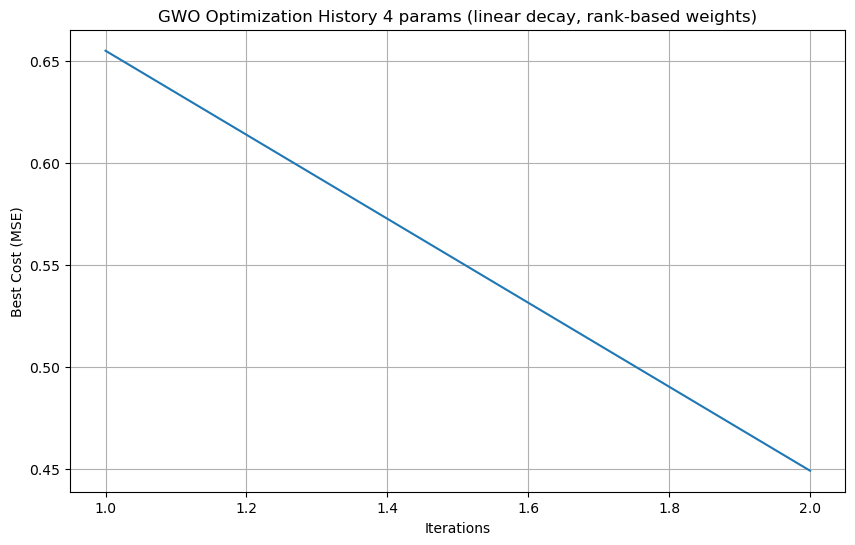

In [ ]:
# Configuration for c1 > c2
options_gwo_linear = {'a_start': 2.0, 'a_end': 0.0, 'decay_type': 'linear', 'weight_type': 'rank_based'}

print("Running GWO with linear decay and rank-based weights ({} iterations)...".format(iters))
best_cost_gwo_linear, best_gwo_linear, cost_history_gwo_linear, mse_gwo_linear = run_pso_and_get_history_GWO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_gwo_linear,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="GWO_linear_rank_based.csv"
)

print(f"Final Best Cost (linear decay, rank-based weights): {best_cost_gwo_linear:.4f}")
print(f"MSE on Test Set (linear decay, rank-based weights): {mse_gwo_linear:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gwo_linear)
plt.title('GWO Optimization History 4 params (linear decay, rank-based weights)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


Running GWO with exponential decay and rank-based weights (2 iterations)...


GWO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: GWO_exponential_rank_based.csv
Final Best Cost (exponential decay, rank-based weights): 0.4705
MSE on Test Set (exponential decay, rank-based weights): 0.6393


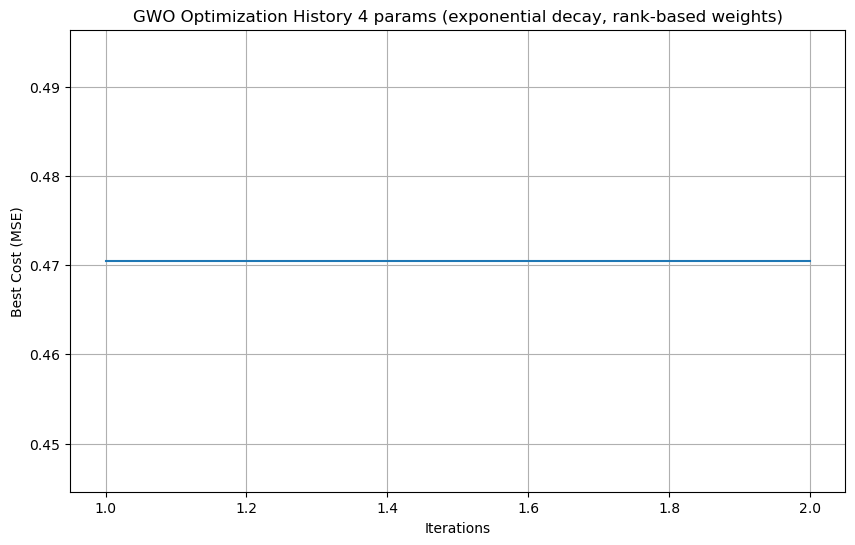

In [ ]:
# Configuration for c1 > c2
options_gwo_exponential = {'a_start': 2.0, 'a_end': 0.0, 'decay_type': 'exponential', 'weight_type': 'rank_based'}

print("Running GWO with exponential decay and rank-based weights ({} iterations)...".format(iters))
best_cost_gwo_exponential, best_gwo_exponential, cost_history_gwo_exponential, mse_gwo_exponential = run_pso_and_get_history_GWO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_gwo_exponential,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="GWO_exponential_rank_based.csv"
)

print(f"Final Best Cost (exponential decay, rank-based weights): {best_cost_gwo_exponential:.4f}")
print(f"MSE on Test Set (exponential decay, rank-based weights): {mse_gwo_exponential:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gwo_exponential)
plt.title('GWO Optimization History 4 params (exponential decay, rank-based weights)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


Running GWO with quadratic decay and rank-based weights (2 iterations)...


GWO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: GWO_quadratic_rank_based.csv
Final Best Cost (quadratic decay, rank-based weights): 0.5525
MSE on Test Set (quadratic decay, rank-based weights): 1.0558


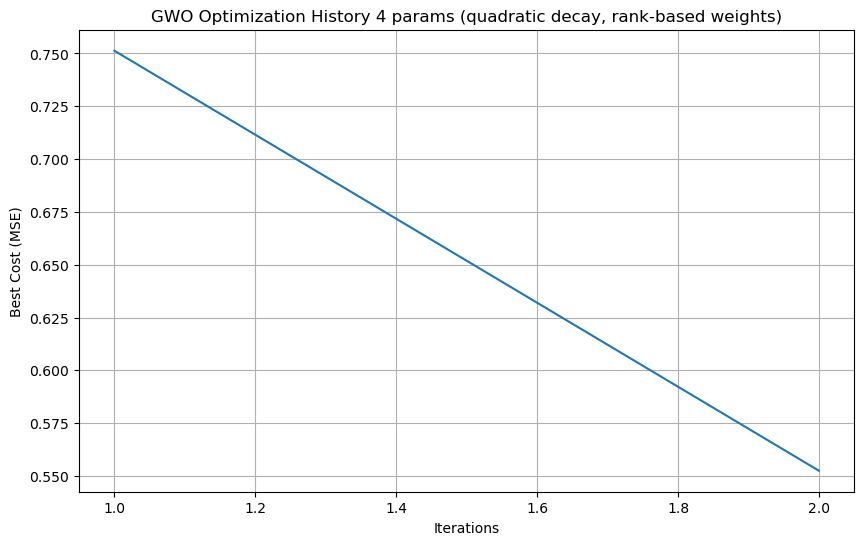

In [122]:
# Configuration for c1 > c2
options_gwo_quadratic = {'a_start': 2.0, 'a_end': 0.0, 'decay_type': 'quadratic', 'weight_type': 'rank_based'}

print("Running GWO with quadratic decay and rank-based weights ({} iterations)...".format(iters))
best_cost_gwo_quadratic, best_gwo_quadratic, cost_history_gwo_quadratic, mse_gwo_quadratic = run_pso_and_get_history_GWO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_gwo_quadratic,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="GWO_quadratic_rank_based.csv"
)

print(f"Final Best Cost (quadratic decay, rank-based weights): {best_cost_gwo_quadratic:.4f}")
print(f"MSE on Test Set (quadratic decay, rank-based weights): {mse_gwo_quadratic:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gwo_quadratic)
plt.title('GWO Optimization History 4 params (quadratic decay, rank-based weights)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


Running GWO with linear decay and fitness-based weights (2 iterations)...


GWO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: GWO_linear_fitness_based.csv
Final Best Cost (linear decay, fitness-based weights): 0.5352
MSE on Test Set (linear decay, fitness-based weights): 0.7440


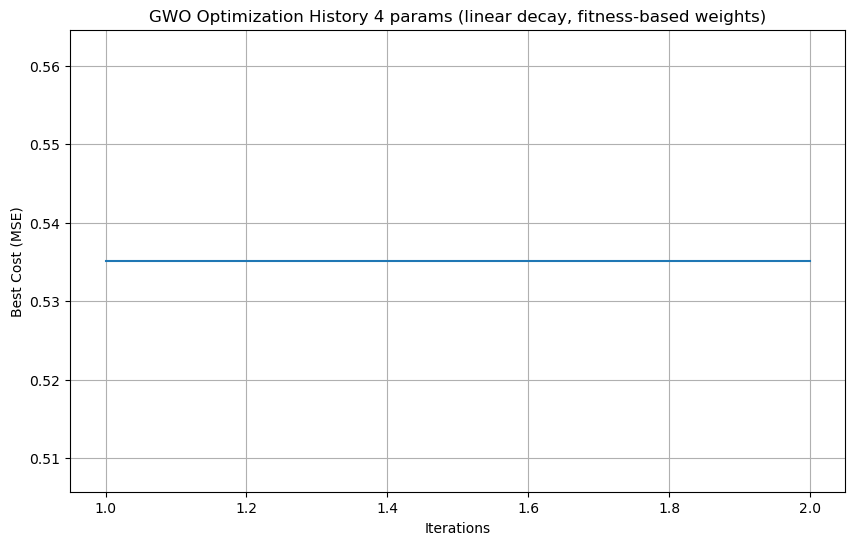

In [121]:
# Configuration for c1 > c2
options_gwo_linear_fitness = {'a_start': 2.0, 'a_end': 0.0, 'decay_type': 'linear', 'weight_type': 'fitness_based'}

print("Running GWO with linear decay and fitness-based weights ({} iterations)...".format(iters))
best_cost_gwo_linear_fitness, best_gwo_linear_fitness, cost_history_gwo_linear_fitness, mse_gwo_linear_fitness = run_pso_and_get_history_GWO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_gwo_linear_fitness,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="GWO_linear_fitness_based.csv"
)

print(f"Final Best Cost (linear decay, fitness-based weights): {best_cost_gwo_linear_fitness:.4f}")
print(f"MSE on Test Set (linear decay, fitness-based weights): {mse_gwo_linear_fitness:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gwo_linear_fitness)
plt.title('GWO Optimization History 4 params (linear decay, fitness-based weights)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


Running GWO with linear decay and equal weights (2 iterations)...


GWO Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Zapisano historię optymalizacji do pliku: GWO_linear_equal.csv
Final Best Cost (linear decay, equal weights): 0.4935
MSE on Test Set (linear decay, equal weights): 0.8162


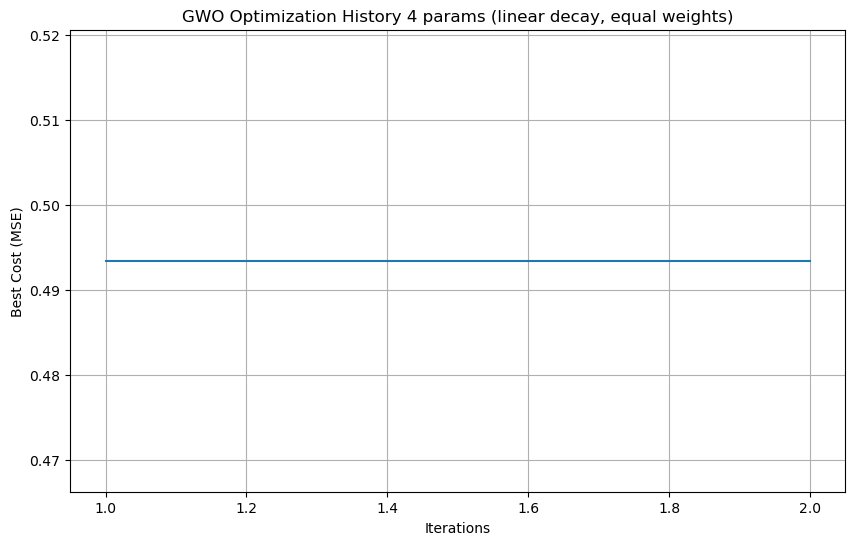

In [123]:
# Configuration for c1 > c2
options_gwo_linear_equal = {'a_start': 2.0, 'a_end': 0.0, 'decay_type': 'linear', 'weight_type': 'equal'}

print("Running GWO with linear decay and equal weights ({} iterations)...".format(iters))
best_cost_gwo_linear_equal, best_gwo_linear_equal, cost_history_gwo_linear_equal, mse_gwo_linear_equal = run_pso_and_get_history_GWO(
    n_particles=n_particles,
    dimensions=dimensions,
    iters=iters,
    options=options_gwo_linear_equal,
    pso_bounds=pso_bounds,
    fitness_function=fitness_function,
    X_test=X_test,
    y_test=y_test,
    csv_filename="GWO_linear_equal.csv"
)

print(f"Final Best Cost (linear decay, equal weights): {best_cost_gwo_linear_equal:.4f}")
print(f"MSE on Test Set (linear decay, equal weights): {mse_gwo_linear_equal:.4f}")

# Plot the cost history
plt.figure(figsize=(10, 6))
plt.plot(range(1, iters + 1), cost_history_gwo_linear_equal)
plt.title('GWO Optimization History 4 params (linear decay, equal weights)')
plt.xlabel('Iterations')
plt.ylabel('Best Cost (MSE)')
plt.grid(True)
plt.show()


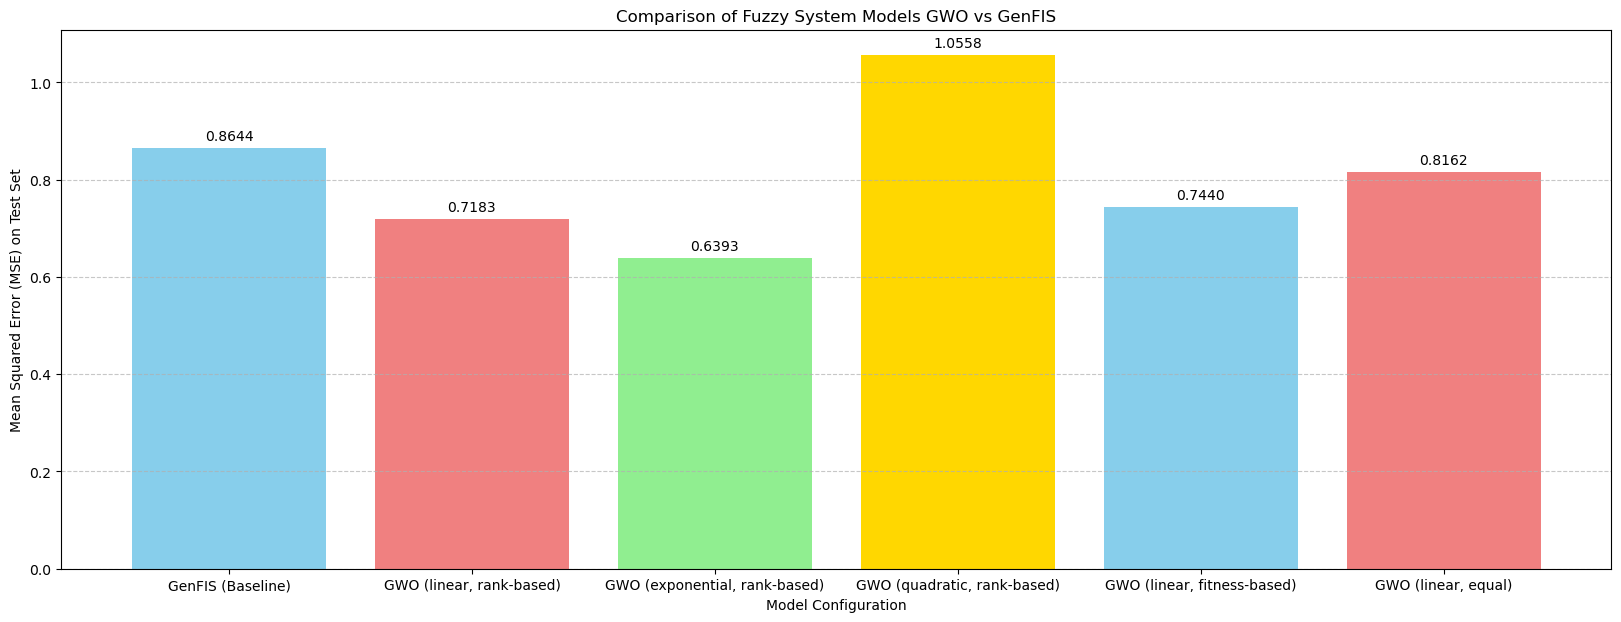

In [125]:
# Data for comparison
model_names = [
    "GenFIS (Baseline)",
    "GWO (linear, rank-based)",
    "GWO (exponential, rank-based)",
    "GWO (quadratic, rank-based)",
    "GWO (linear, fitness-based)",
    "GWO (linear, equal)"
]

mse_values = [
    mse_genfis,
    mse_gwo_linear,
    mse_gwo_exponential,
    mse_gwo_quadratic,
    mse_gwo_linear_fitness,
    mse_gwo_linear_equal
]

plt.figure(figsize=(20, 7))
plt.bar(model_names, mse_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Model Configuration')
plt.ylabel('Mean Squared Error (MSE) on Test Set')
plt.title('Comparison of Fuzzy System Models GWO vs GenFIS')
plt.ylim(bottom=0) # Ensure y-axis starts from 0

for i, mse in enumerate(mse_values):
    plt.text(i, mse + 0.01, f'{mse:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
